# 实验一 · 轨迹数据预处理完成版

对应教师 `作业1轨迹数据预处理.ipynb`。原 starter 保留；本完成版复用经过核验的同一套实现，依次展示 S 分段/过滤、D 方向删除、P 简化、三组参数、六种顺序、评价与真实 AI 批判，最后实际全量复算。

**默认 FULL_RECOMPUTE**：历史参数/顺序从 raw 重算 9,720 个记录—候选配对，再从全部 11,386 条原始记录重算冻结 R0/最终策略，并从本次新结果重新生成图与画图数据。`LIVE` 不在本 Notebook 自动开启。历史 G2 结果、最终确认样本、全量生产三者保持独立身份。可用 `SC_LAB1_RECOMPUTE_WORK` 指定工程外的新输出目录；不设置则创建临时目录，不覆盖已有非空结果。

姓名：吴博闻；学号：`10245102410`。报告修订日期：2026-09-28；实验实际时间以各原始运行记录为准。当前为待审交付，用户理解审核尚未完成，未提交教师。

In [1]:
from pathlib import Path
import contextlib, csv, gzip, hashlib, html, io, json, os, platform, re, sys, tempfile
from IPython.display import display, HTML, Image, Markdown

# 从 Notebook 所在位置或启动目录向上找项目；不依赖个人绝对路径和 ROOT/.venv。
start = Path.cwd().resolve()
ROOT = next((p for p in (start, *start.parents)
             if (p/'task1/goal3').is_dir()), None)
if ROOT is None:
    raise RuntimeError('请把 Notebook 放在完整提交包中，或从项目目录启动。')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
MODE = 'FULL_RECOMPUTE'
ENABLE_LIVE = False
assert MODE == 'FULL_RECOMPUTE' and ENABLE_LIVE is False
explicit_work = os.environ.get('SC_LAB1_RECOMPUTE_WORK')
if explicit_work:
    WORK = Path(explicit_work).expanduser().resolve()
    if WORK == ROOT or ROOT in WORK.parents:
        raise RuntimeError('显式复算目录必须位于当前工程/解压包之外。')
    if WORK.exists() and (not WORK.is_dir() or any(WORK.iterdir())):
        raise RuntimeError('显式复算目录已存在且非空，拒绝覆盖。')
    WORK.mkdir(parents=True, exist_ok=True)
else:
    WORK = Path(tempfile.mkdtemp(prefix='sc-lab1-full-')).resolve()

from task1.workflow.io import digest, object_hash, read_json, write_json
from task1.workflow.io import ROOT as MODULE_ROOT
from task1.workflow.g2_provider import ExperimentProvider
from task1.workflow.provider import CodexProvider
from task1.goal3.reproduce import recompute_historical, recompute_production
assert MODULE_ROOT.resolve() == ROOT, '模块必须来自当前工程/解压包，不能借用原工作区。'

# 本内核实际拦截两个已登记 Provider 入口；出现调用立即失败，不回退到 Mock。
provider_observation = {'attempted_new_calls': 0}
def forbid_provider(*args, **kwargs):
    provider_observation['attempted_new_calls'] += 1
    raise RuntimeError('FULL_RECOMPUTE 禁止新增模型调用')
_original_experiment_call = ExperimentProvider.call
_original_governance_call = CodexProvider.call
ExperimentProvider.call = forbid_provider
CodexProvider.call = forbid_provider

G2 = ROOT/'task1/evidence/goal2'
G3 = ROOT/'task1/evidence/goal3'
stage = read_json(G2/'result_summary.json')
memory_path = ROOT/stage['memory']['snapshot_path']
memory_hash_before = digest(memory_path)
assert memory_hash_before == stage['memory']['snapshot_sha256']
raw_path = ROOT/'task1/作业/作业/traj_dict.json'
assert digest(raw_path) == stage['data']['raw_sha256']

# 只有当前生产已冻结并有真实 run 时才执行本完成版，不临时用样本替代 full。
if not (G3/'current_runs.json').is_file() or not (G3/'production_freeze.json').is_file():
    raise RuntimeError('G3 正式生产尚未登记；保持源文件待执行，不把 fast 样本冒充 full。')

def show(rows, columns=None, limit=20):
    rows = list(rows)
    if not rows:
        print('无对应行；不填造数值。')
        return
    columns = columns or list(rows[0])
    def cell(value):
        if value is None: return '不可用（见相应原因）'
        if isinstance(value, (dict,list)): value=json.dumps(value,ensure_ascii=False)
        return html.escape(str(value))
    head='<tr>'+''.join('<th>'+cell(c)+'</th>' for c in columns)+'</tr>'
    body=''.join('<tr>'+''.join('<td>'+cell(r.get(c))+'</td>' for c in columns)+'</tr>' for r in rows[:limit])
    display(HTML('<table style="border-collapse:collapse" border="1">'+head+body+'</table>'))
    if len(rows)>limit: print(f'显示前 {limit} / {len(rows)} 行；完整记录保留于来源文件。')

def figure(name, phase='goal2', width=950):
    path=ROOT/'task1/figures'/phase/(name+'.png')
    if not path.is_file(): raise FileNotFoundError('正式图不存在：'+str(path.relative_to(ROOT)))
    display(Markdown('**已归档正式图：** '+phase+' / '+name+'（历史解释材料）'))
    display(Image(filename=str(path),width=width))

def recomputed_figure(topic, name, width=950):
    directory=WORK/topic/'figures'
    manifest=read_json(directory/'figure_manifest.json')
    assert manifest['old_summary_or_figure_read_for_plotting'] is False
    entry=next(f for f in manifest['figures'] if f['name']==name)
    path=directory/entry['files']['png']['path']
    assert digest(path)==entry['files']['png']['sha256']
    assert digest(directory/'plot_data.json')==manifest['plot_data_sha256']
    display(Markdown('**本次 FULL 从 raw 重新计算并绘制：** '+name))
    display(Image(filename=str(path),width=width))

def run_logged(label, fn):
    capture=io.StringIO()
    with contextlib.redirect_stdout(capture):
        result=fn()
    (WORK/(label+'_progress.txt')).write_text(capture.getvalue(),encoding='utf8')
    assert result['status']=='VERIFIED' and result['new_model_calls']==0
    print({k:v for k,v in result.items() if k not in {'checks','selections'}})
    return result

def current_manifest(partition):
    index=read_json(G3/'current_runs.json')
    found=[]
    for run_id in index.values():
        if not isinstance(run_id,str): continue
        path=G3/'runs'/run_id/'manifest.json'
        if path.is_file():
            value=read_json(path)
            if value.get('partition')==partition: found.append((path,value))
    if len(found)!=1: raise RuntimeError('当前 run 索引没有唯一分区：'+partition)
    return found[0]

_, deployment_manifest=current_manifest('FULL_PRODUCTION')
if (deployment_manifest.get('status')!='MACHINE_VERIFIED_PENDING_C'
        or deployment_manifest['input_ids']!=deployment_manifest['completed_record_ids']):
    raise RuntimeError('当前生产尚未完整完成；不执行待验收Notebook。')

print('FULL_RECOMPUTE；Python',platform.python_version(),'; 新模型调用由实际 Provider 哨兵检查。')
print('数据：',stage['data']['raw_records'],'条 /',stage['data']['raw_points'],'点；source_crs=UNVERIFIED。')

FULL_RECOMPUTE；Python 3.12.3 ; 新模型调用由实际 Provider 哨兵检查。
数据： 11386 条 / 1173410 点；source_crs=UNVERIFIED。


## 1. 数据与条件化坐标

输入原始坐标/时间不覆盖。工作坐标固定椭球 `a=6378137 m, 1/f=298.257223563`、`h=0`、ENU 中心 `(121.343555°,31.3561015°)`。数值核对不能证明源 datum；零时间差速度、零位移方向分别记为不可计算。以下只用已暴露的 pilot 记录 246 演示单条步骤，不从最终确认集挑案例。

In [2]:
from task1.workflow.g2_data import raw_data, adapt
from task1.workflow.g2_pipeline import run_record, REFERENCE_PARAMETERS, DIRECTION_METHOD
from task1.workflow.g2_metrics import review_record
from task1.workflow.geometry import (split_trajectory, filter_segments, denoise_trajectory,
                                    douglas_peucker_indices, select_indices, recompute_features)
raw=raw_data()
pilot=adapt('246',raw['246'])
print('演示身份：已暴露 PILOT 246；原始点数',len(pilot['indices']))
print('教学参考参数',REFERENCE_PARAMETERS)
features=recompute_features(pilot,time_reliable=True)
show(features['edges'][:8],['from_index','to_index','dt','distance','speed','speed_reason','direction_degrees','direction_reason'])

演示身份：已暴露 PILOT 246；原始点数 108
教学参考参数 {'dt': 30, 'distance': 400, 'min_points': 5, 'min_length': 65, 'direction': 35, 'dp': 5}


from_index,to_index,dt,distance,speed,speed_reason,direction_degrees,direction_reason
0,1,7,1.0997077325179991,0.15710110464542845,不可用（见相应原因）,72.36717872281527,不可用（见相应原因）
1,2,20,1.4965836182500356,0.07482918091250178,不可用（见相应原因）,72.73498112334407,不可用（见相应原因）
2,3,10,0.34599885416285686,0.03459988541628568,不可用（见相应原因）,343.9864201526183,不可用（见相应原因）
3,4,10,0.29239063512813873,0.029239063512813874,不可用（见相应原因）,319.2949351606239,不可用（见相应原因）
4,5,10,0.2858723700163614,0.02858723700163614,不可用（见相应原因）,269.97263003978844,不可用（见相应原因）
5,6,10,0.3969609147782863,0.039696091477828634,不可用（见相应原因）,286.1913057271124,不可用（见相应原因）
6,7,20,0.8646574936546763,0.04323287468273381,不可用（见相应原因）,26.12931223113914,不可用（见相应原因）
7,8,20,76.99950084071651,3.849975042035825,不可用（见相应原因）,293.2997358837098,不可用（见相应原因）


## 2. 完成三个基础 TODO

### S：先断边，再按完整段过滤

`dt > 阈值`、负时间差或距离 `> 阈值` 才断开；等号不切，右点属于新段。短段依据段内累计长度与点数判定，断开的边不计入长度。下面是教师 TODO 对应的可读调用入口，核心数学只有模块内一份。

In [3]:
def segmentation(record, dt=30, distance=400, min_points=5, min_length=65):
    split=split_trajectory(record,dt,distance,time_reliable=True)
    filtered=filter_segments(split['segments'],min_points,min_length,time_reliable=True)
    return {'boundaries':split['boundaries'],'kept':filtered['kept'],'dropped':filtered['dropped']}

segmented=segmentation(pilot)
print('原始断点:',segmented['boundaries'])
show([{'kept':keep,'original_indices':part['indices'],
       'length_work_m':part['features']['length'],
       'filter_reasons':part.get('filter_reasons',[])}
      for keep,key in [(True,'kept'),(False,'dropped')] for part in segmented[key]])

原始断点: []


kept,original_indices,length_work_m,filter_reasons
True,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107]",11326.480988154068,[]


### D：完整标记后同时删除

当前至后继为出边方向；与前后出边方向的圆周差都严格大于阈值才标记。一次标记、同时删除，不迭代；首尾及必要方向不可计算窗口保留并标记，下游重算特征。没有未知物理限速或“低位移就可靠”的假设。

In [4]:
def denoising(segment,direction=35):
    return denoise_trajectory(segment,direction,method=DIRECTION_METHOD,time_reliable=True)

denoised=[denoising(part) for part in segmented['kept']]
show([{'segment':i,'input_points':len(part['indices']),
       'deleted_indices':result['deleted_indices'],
       'remaining_points':len(result['record']['indices'])}
      for i,(part,result) in enumerate(zip(segmented['kept'],denoised))])

segment,input_points,deleted_indices,remaining_points
0,108,"[6, 20, 48]",105


### P：有限线段的 Douglas–Peucker

把点向有限端点线段投影，投影位置夹在 `[0,1]`；端点重合用点到端点距离。最大偏差严格超过容差时递归。`dp=0` 明确作为全部保留参考。输出沿用原始身份，不插值、不改坐标和时间。

In [5]:
def simplification(segment,dp=5):
    kept=douglas_peucker_indices(segment['xy'],dp,segment['indices'])
    return select_indices(segment,kept,time_reliable=True)

simplified=[simplification(result['record']) for result in denoised]
show([{'segment':i,'P_input':len(clean['record']['indices']),
       'P_output':len(final['indices']),'retained_original_indices':final['indices']}
      for i,(clean,final) in enumerate(zip(denoised,simplified))])

# 已知数学答案用于理解距离定义，非真实数据噪声标签。
from task1.workflow.geometry import point_segment_distance
print('越过端点的点到有限线段距离：',point_segment_distance((2,1),(0,0),(1,0)))

segment,P_input,P_output,retained_original_indices
0,105,36,"[0, 9, 12, 26, 27, 33, 35, 37, 39, 41, 43, 44, 46, 47, 49, 50, 51, 52, 53, 55, 59, 60, 61, 62, 69, 70, 71, 80, 81, 82, 85, 89, 94, 104, 106, 107]"


越过端点的点到有限线段距离： 1.4142135623730951


## 3. 主函数、动作账本与真实前后案例

`run_record` 统一记录每阶段输入/操作/输出，原始点的终态为 filtered、denoised、simplified 或 retained。审核从独立可信 pilot 输入重构，不拿候选自己的 clean 自证。图分别画真实片段，原始断点不重连。

n_input,n_filtered,n_direction_removed,n_dp_removed,n_final,common_covered_points,common_max_error,dp_max_error,raw_break_crossings
108,0,3,69,36,108,111.93999607553866,4.768356861321128,0


original_index,action,reasons
0,retained,"[""FINAL_OUTPUT""]"
1,simplified,"[""DP_WITHIN_TOLERANCE""]"
2,simplified,"[""DP_WITHIN_TOLERANCE""]"
3,simplified,"[""DP_WITHIN_TOLERANCE""]"
4,simplified,"[""DP_WITHIN_TOLERANCE""]"
5,simplified,"[""DP_WITHIN_TOLERANCE""]"
6,denoised,"[""DIRECTION_RULE""]"
7,simplified,"[""DP_WITHIN_TOLERANCE""]"
8,simplified,"[""DP_WITHIN_TOLERANCE""]"
9,retained,"[""FINAL_OUTPUT""]"


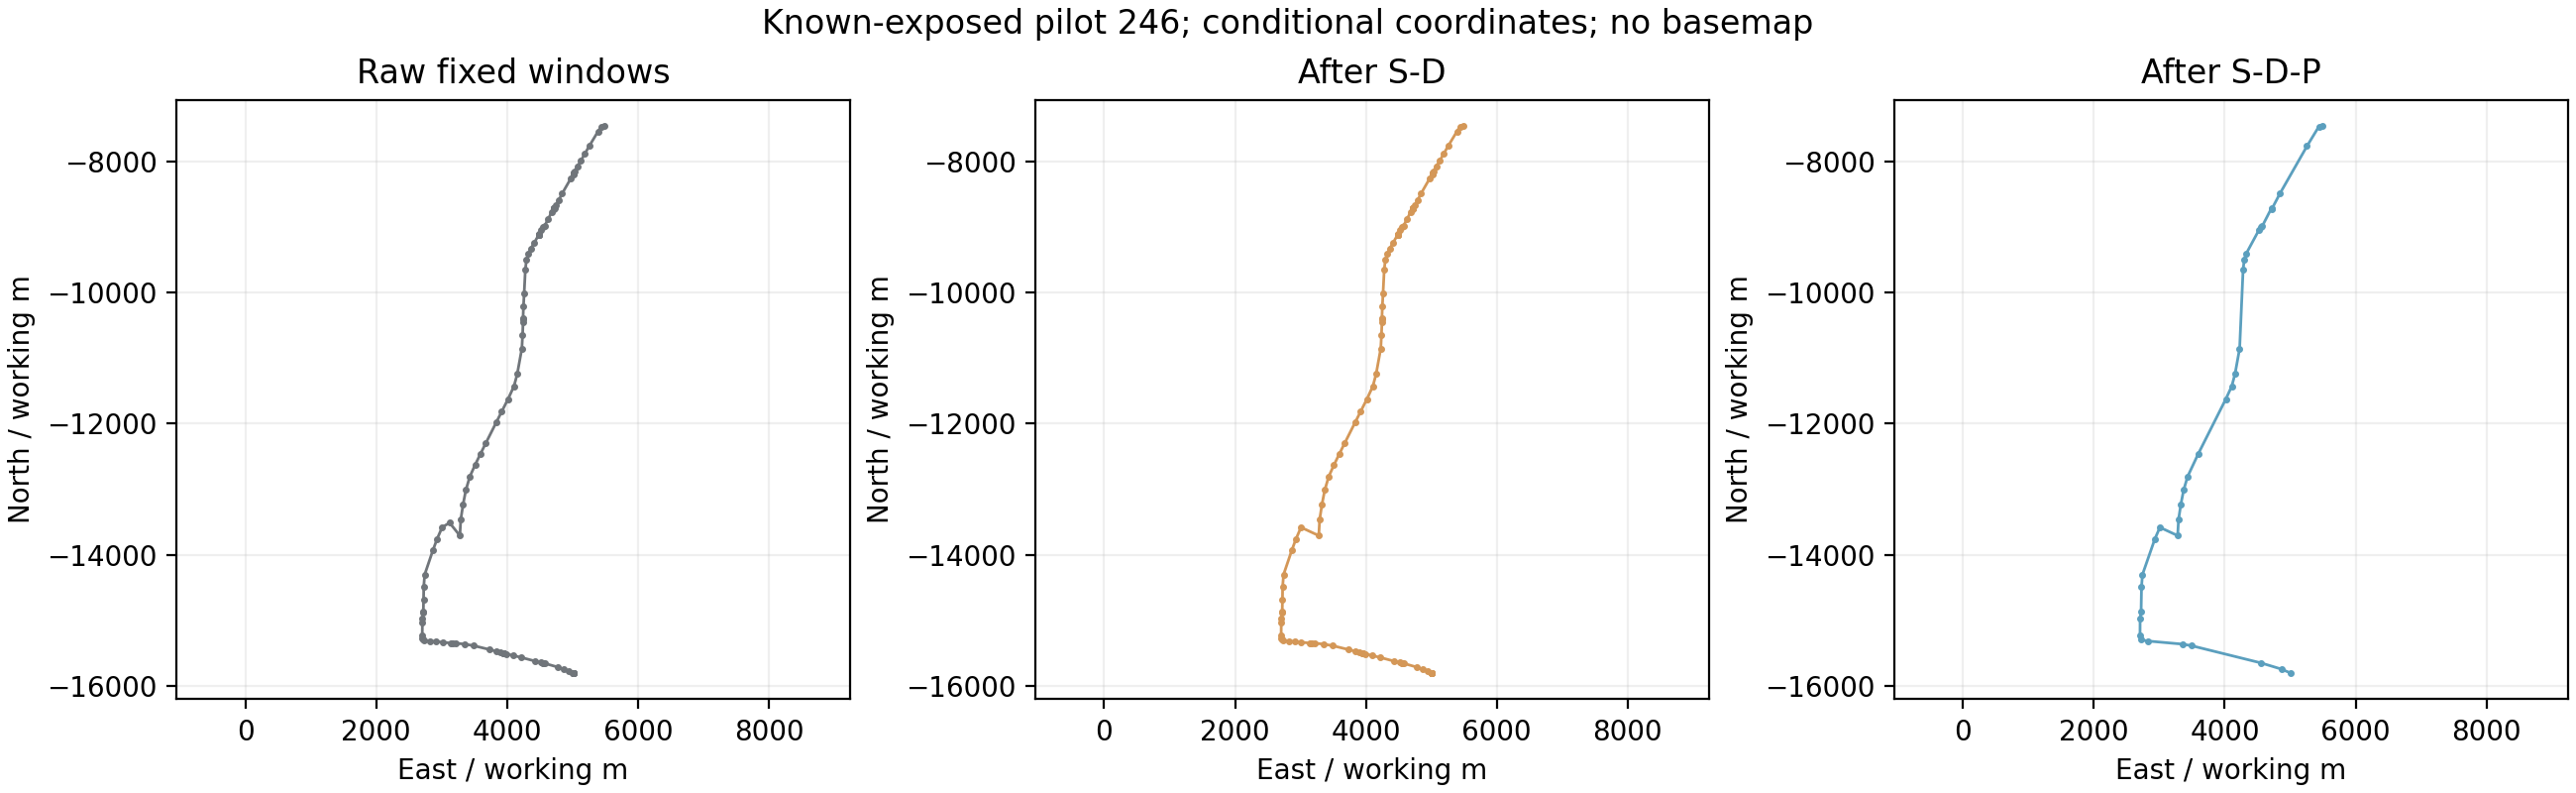

In [6]:
contract_hash=digest(ROOT/'task1/config/goal2/contract.json')
provenance={'source_kind':'CURRENT_NOTEBOOK_EXPOSED_PILOT','record_id':'246','not_new_independent_sample':True}
example=run_record(pilot,dict(REFERENCE_PARAMETERS),'S-D-P',contract_hash=contract_hash,provenance=provenance)
check=review_record(example,pilot,expected_parameters=dict(REFERENCE_PARAMETERS),expected_order='S-D-P',
                    contract_hash=contract_hash,trusted_provenance=provenance)
assert check['status']=='VERIFIED'
show([{k:example['metrics'][k] for k in ['n_input','n_filtered','n_direction_removed','n_dp_removed','n_final',
      'common_covered_points','common_max_error','dp_max_error','raw_break_crossings']}])
show(example['point_actions'][:12],['original_index','action','reasons'])

from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
palette_text=(ROOT/'templates/latex/common/p2_cloud_sorbet_colors.tex').read_text()
palette={name:'#'+value for name,value in re.findall(r'\\definecolor\{([^}]+)\}\{HTML\}\{([0-9A-Fa-f]{6})\}',palette_text)}
raw_windows=split_trajectory(pilot,30,400,time_reliable=True)['segments']
# 原生 Figure/Canvas 文件输出不依赖 IPython 的 pyplot REPL 接口。
fig=Figure(figsize=(13,4),constrained_layout=True)
FigureCanvasAgg(fig)
axes=fig.subplots(1,3)
for ax,title,parts,color in zip(axes,['Raw fixed windows','After S-D','After S-D-P'],
        [raw_windows,example['stages'][1]['output'],example['final_segments']],[palette['Muted'],palette['C2'],palette['C1']]):
    for part in parts:
        if part['xy']:
            x,y=zip(*part['xy']);ax.plot(x,y,'.-',color=color,linewidth=1,markersize=3)
    ax.set_title(title);ax.set_xlabel('East / working m');ax.set_ylabel('North / working m')
    ax.set_aspect('equal',adjustable='datalim');ax.grid(alpha=.2)
fig.suptitle('Known-exposed pilot 246; conditional coordinates; no basemap')
fig.savefig(WORK/'pilot_steps.svg')
fig.savefig(WORK/'pilot_steps.png',dpi=200)
display(Image(filename=str(WORK/'pilot_steps.png'),width=1000))

## 4. 评价逻辑

共同 raw 窗口固定为 dt=30、distance=400（不做短段过滤）。原始点只有被显式保留，或由同一 final 片段内相邻保留索引且处在同一原始窗口夹持，才有共同误差。覆盖分母是原始点；显式保留点、共同覆盖点、P 即时输入分别统计。空输出不删除分母，误差 null 不当作零。

S/D 变化需要参考覆盖集合包含、原来非空记录/窗口不丢失、原始断点跨越0、参考已覆盖集合的最大误差非退化。P 只有相同上游完整输入且满足共同5工作米预算，才比较省点收益。没有噪声真值，不计算真实噪声准确率或主观加权分数。

## 5. 三组参数与六顺序：实际从 raw 完整复算

这一单元恢复 G2 已经发生的参数/顺序实验，检查全部原始结果哈希与可信审核。参数59×120+14×120，顺序6×120+2×120，共9,720个记录—候选配对。输出不是新独立实验，也不是新的 LIVE 模型运行。

{'status': 'VERIFIED', 'mode': 'FULL_RECOMPUTE_HISTORICAL_G2', 'topic': 'parameters', 'new_model_calls': 0, 'candidate_record_recomputations': 9720, 'at': '2026-09-27T16:57:12.265160+00:00', 'elapsed_seconds': 895.0023347790002, 'registry_sha256': 'da9521c2c4ff252c94bd50b9b67c4e90ea8c9a71bb5a7304203d157d071b67f5', 'source_sha256': '440f426ef60acde8475395d9a2dee955a2e6f9fd142cb06b9c67d549a749b334', 'raw_recomputed_plots': {'figure_count': 2, 'manifest_path': 'figures/figure_manifest.json', 'manifest_sha256': 'c164ab71c54cae4b82027be07ee8a9bee0b903836551fc16089b94724327d811', 'plot_data_sha256': '5c4af348429fe64e2e6bceea20008541af32d9da6806bd7e5eba4410bc5e9320', 'lineage': 'newly recomputed raw results; historical targets used only for equality checks'}}


**本次 FULL 从 raw 重新计算并绘制：** recomputed_parameters

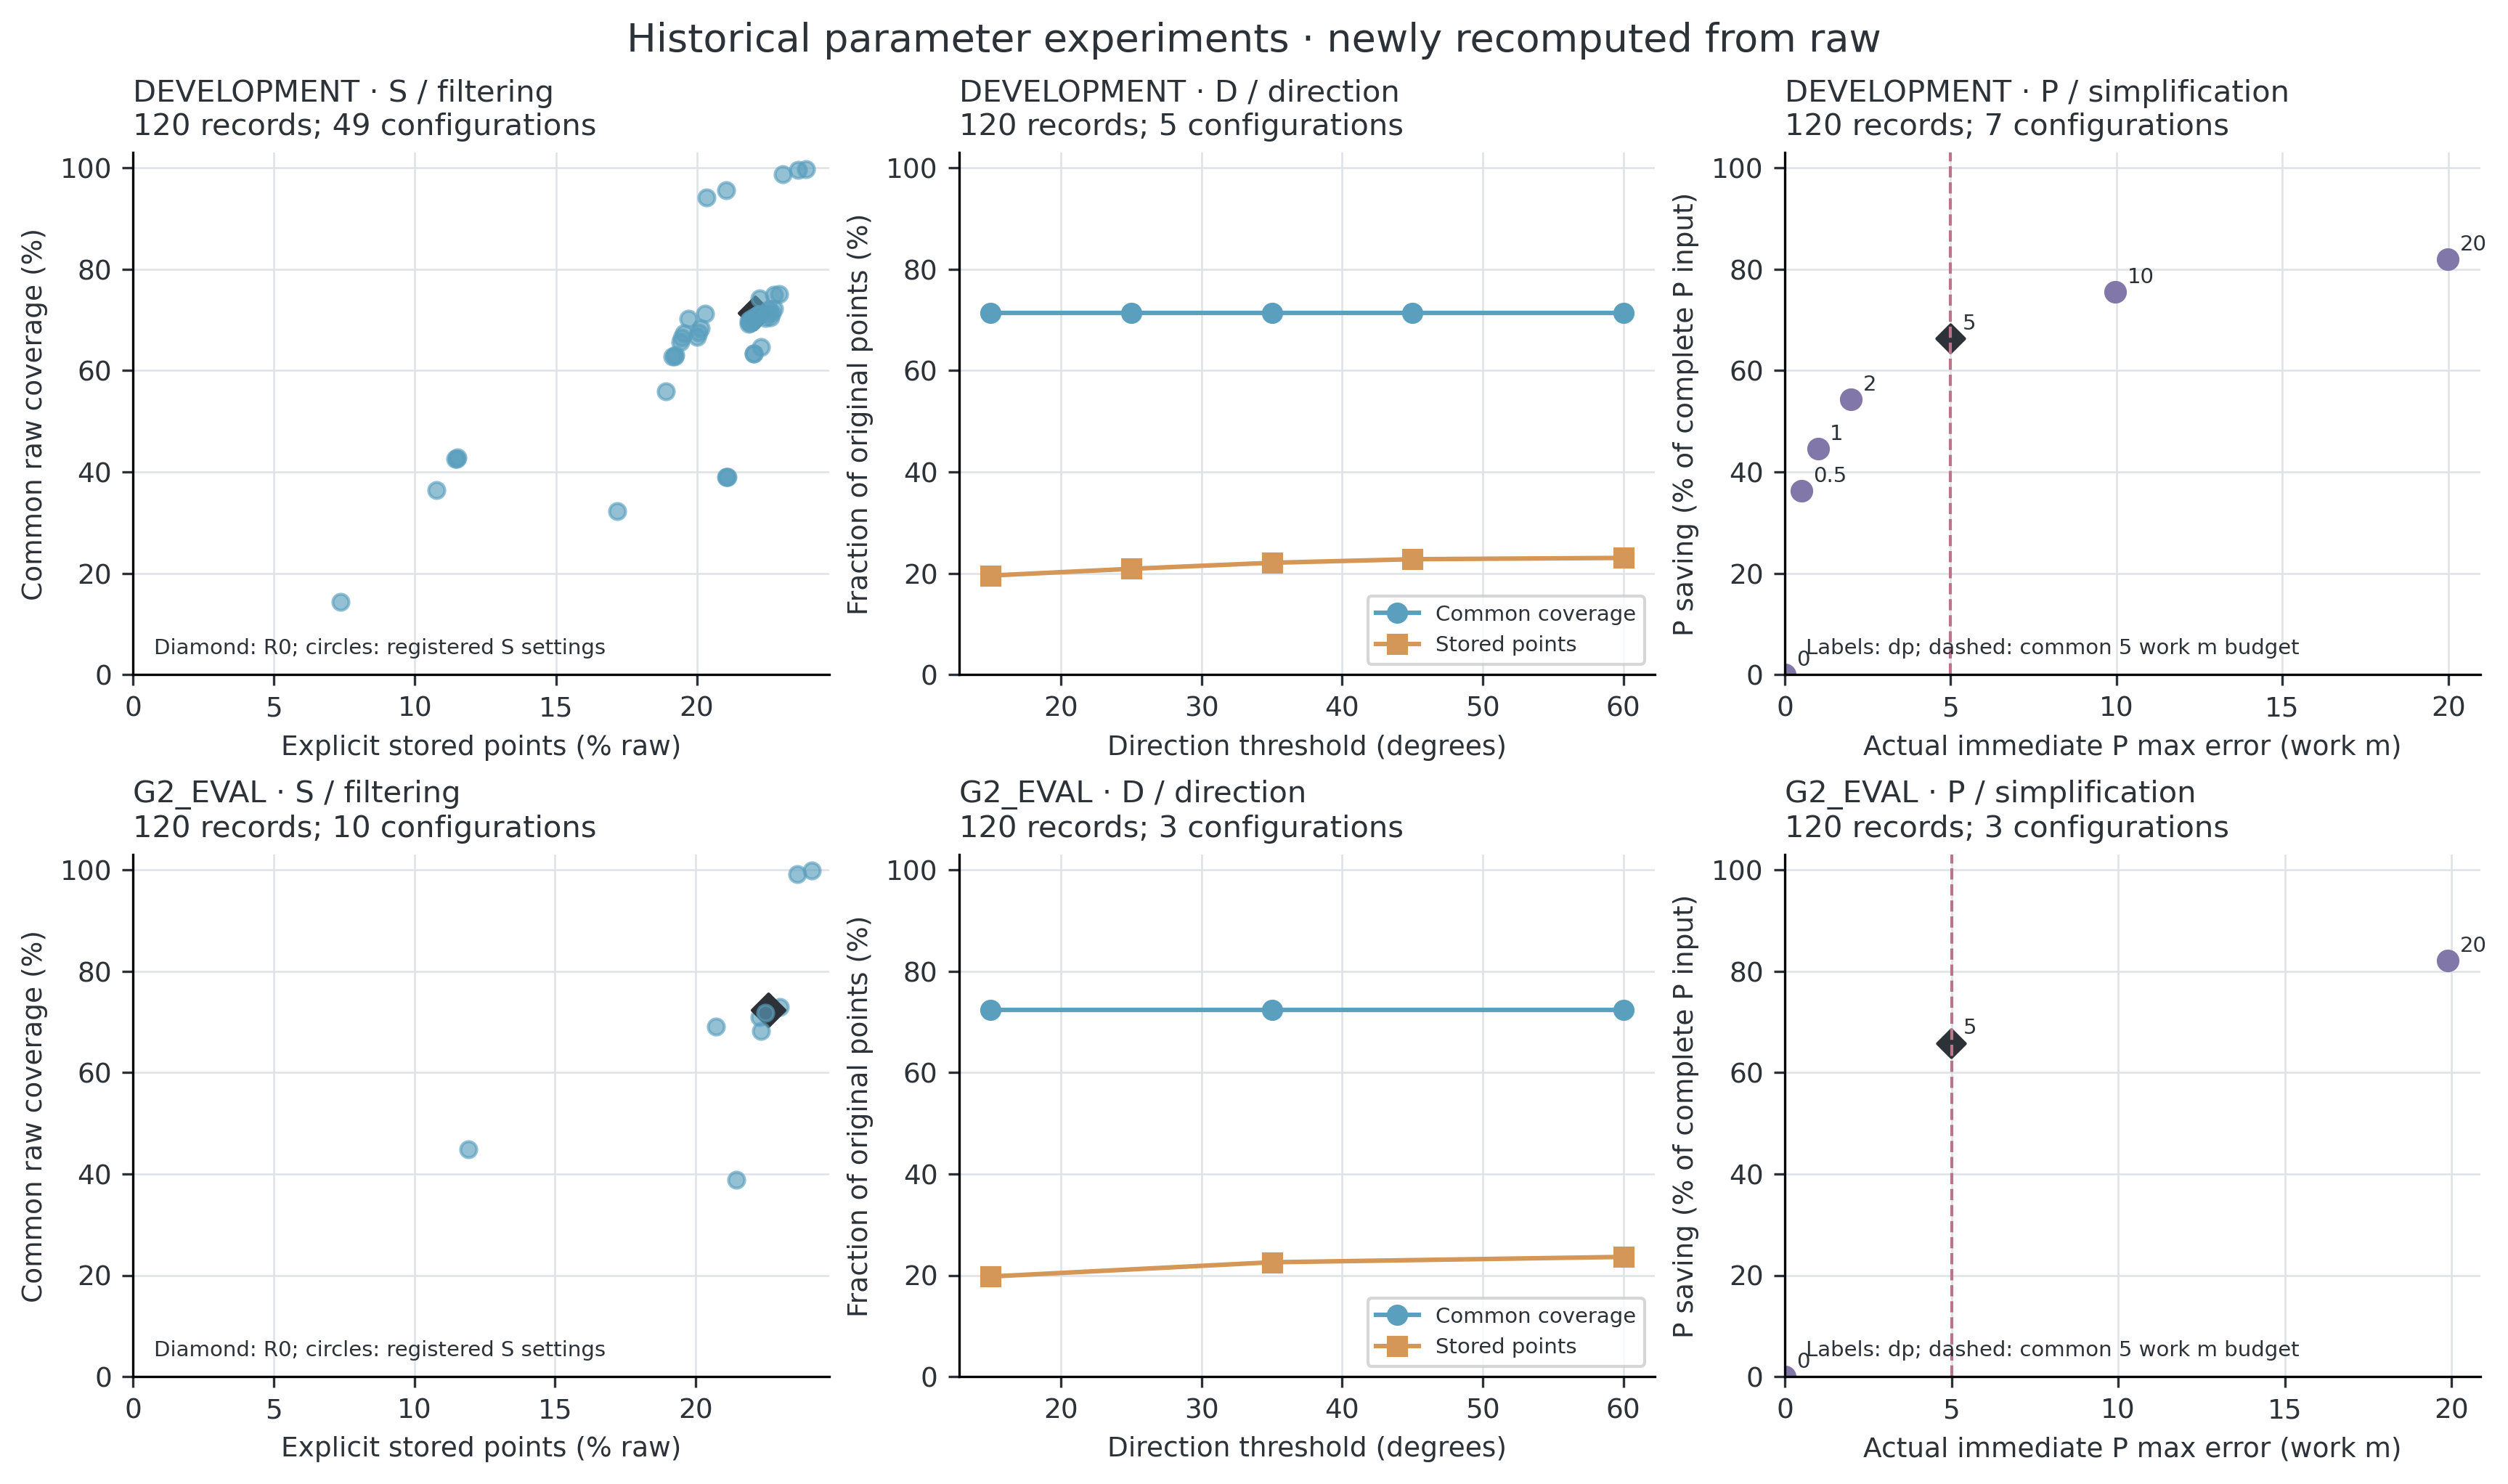

**本次 FULL 从 raw 重新计算并绘制：** recomputed_orders

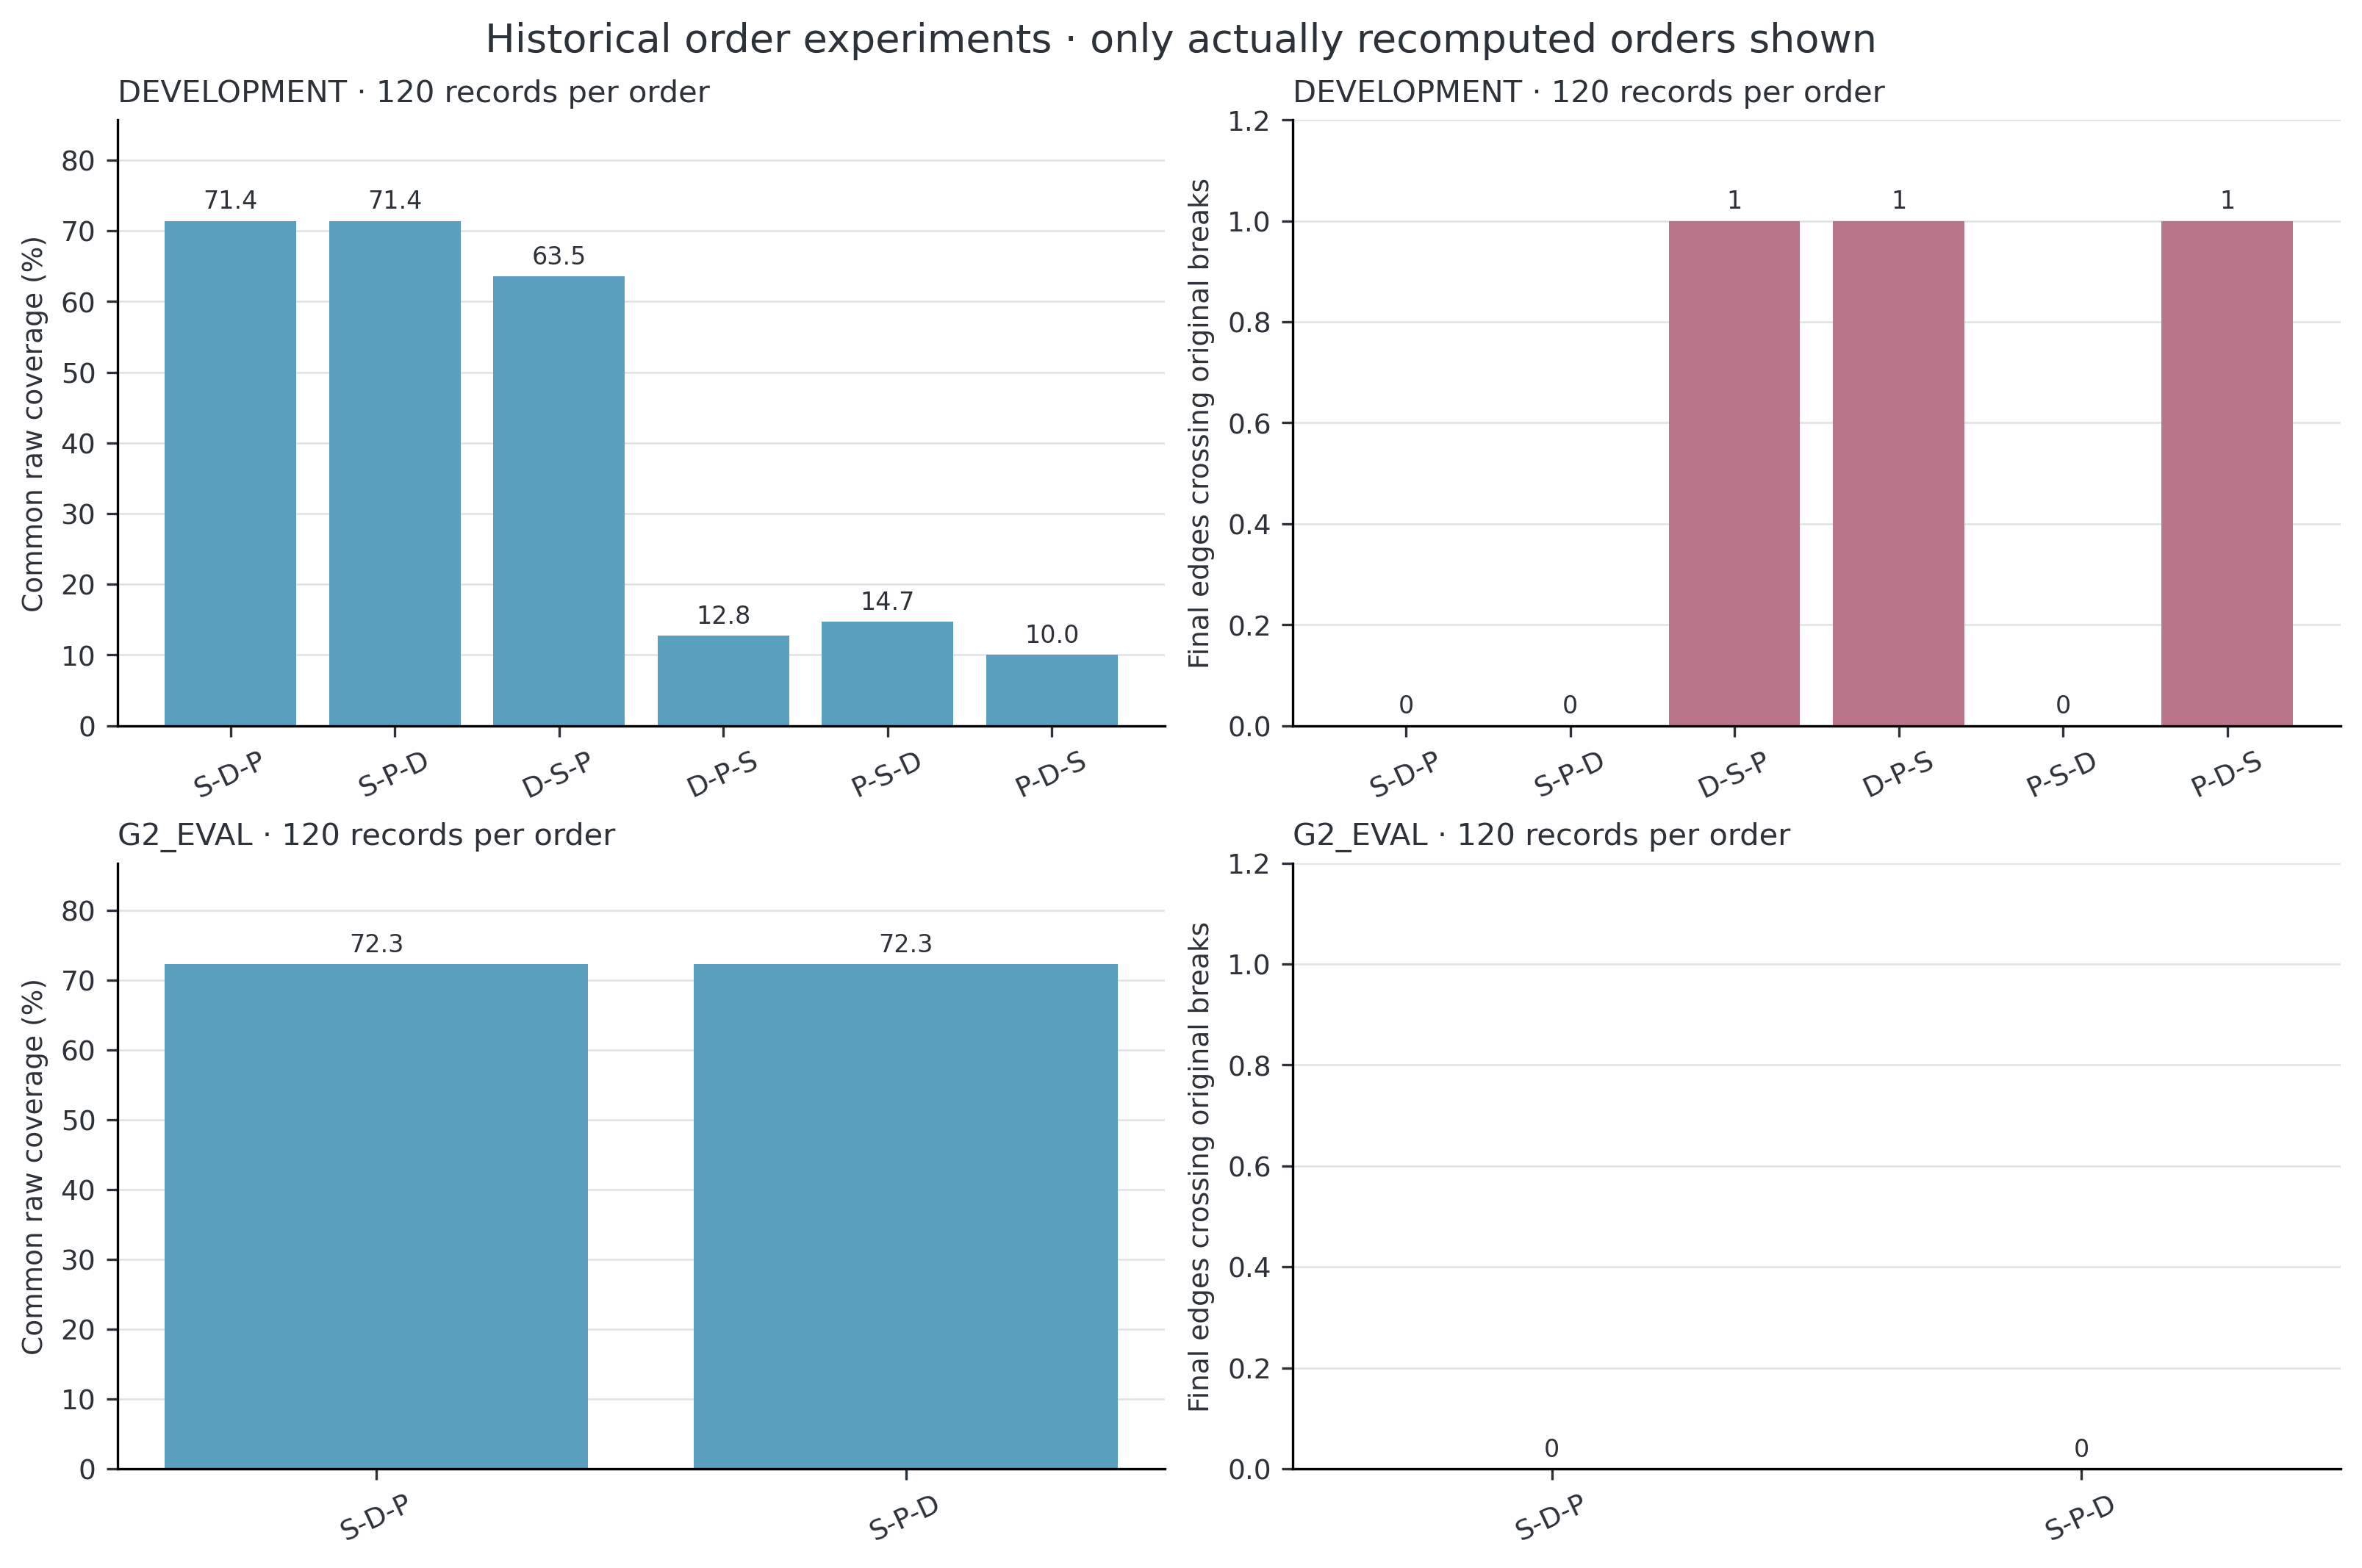

parameter,registered_values
dt,"[15, 20, 30, 45, 60]"
distance,"[95, 200, 400, 600, 800]"
min_points,"[2, 3, 5, 7, 10]"
min_length,"[0, 32.5, 65, 97.5, 130]"
direction,"[15, 25, 35, 45, 60]"
dp,"[0, 0.5, 1, 2, 5, 10, 20]"


candidate,dt,distance,min_points,min_length,direction,dp,n_records,strict_gain_records,common_covered_points,n_final,evaluation_status
C-S,30,400,2,0,35,5,120,53,12162,2939,SUPPORTED_WITHIN_SCOPE
C-D,30,400,5,65,35,5,120,0,8805,2748,NO_DEMONSTRATED_GAIN
C-P,30,400,5,65,35,5,120,0,8805,2748,NO_DEMONSTRATED_GAIN


In [7]:
parameter_recompute=run_logged('parameters',lambda:recompute_historical('parameters',WORK/'parameters'))
assert parameter_recompute['candidate_record_recomputations']==9720
recomputed_figure('parameters','recomputed_parameters')
recomputed_figure('parameters','recomputed_orders')
show([{'parameter':k,'registered_values':v} for k,v in stage['parameters']['grid'].items()])
show(stage['single_candidates'],['candidate','dt','distance','min_points','min_length','direction','dp',
                                'n_records','strict_gain_records','common_covered_points','n_final','evaluation_status'])

### 参数结果如何解释

C-S（G3称S0）只把 min_points=5→2、min_length=65→0，其余参考参数不变；G2评估120条有53条严格改善，共同覆盖8805→12162，无输出32→0。C-D、C-P仍是R0，不能说成两个新组件。新增覆盖不证明点干净；改变S/D后P省点率的变化也不证明DP变好。上方图是本次 raw 复算后新绘；以下三张已归档 G2 图保留更细的历史解释。

**已归档正式图：** goal2 / segmentation_filter_grids（历史解释材料）

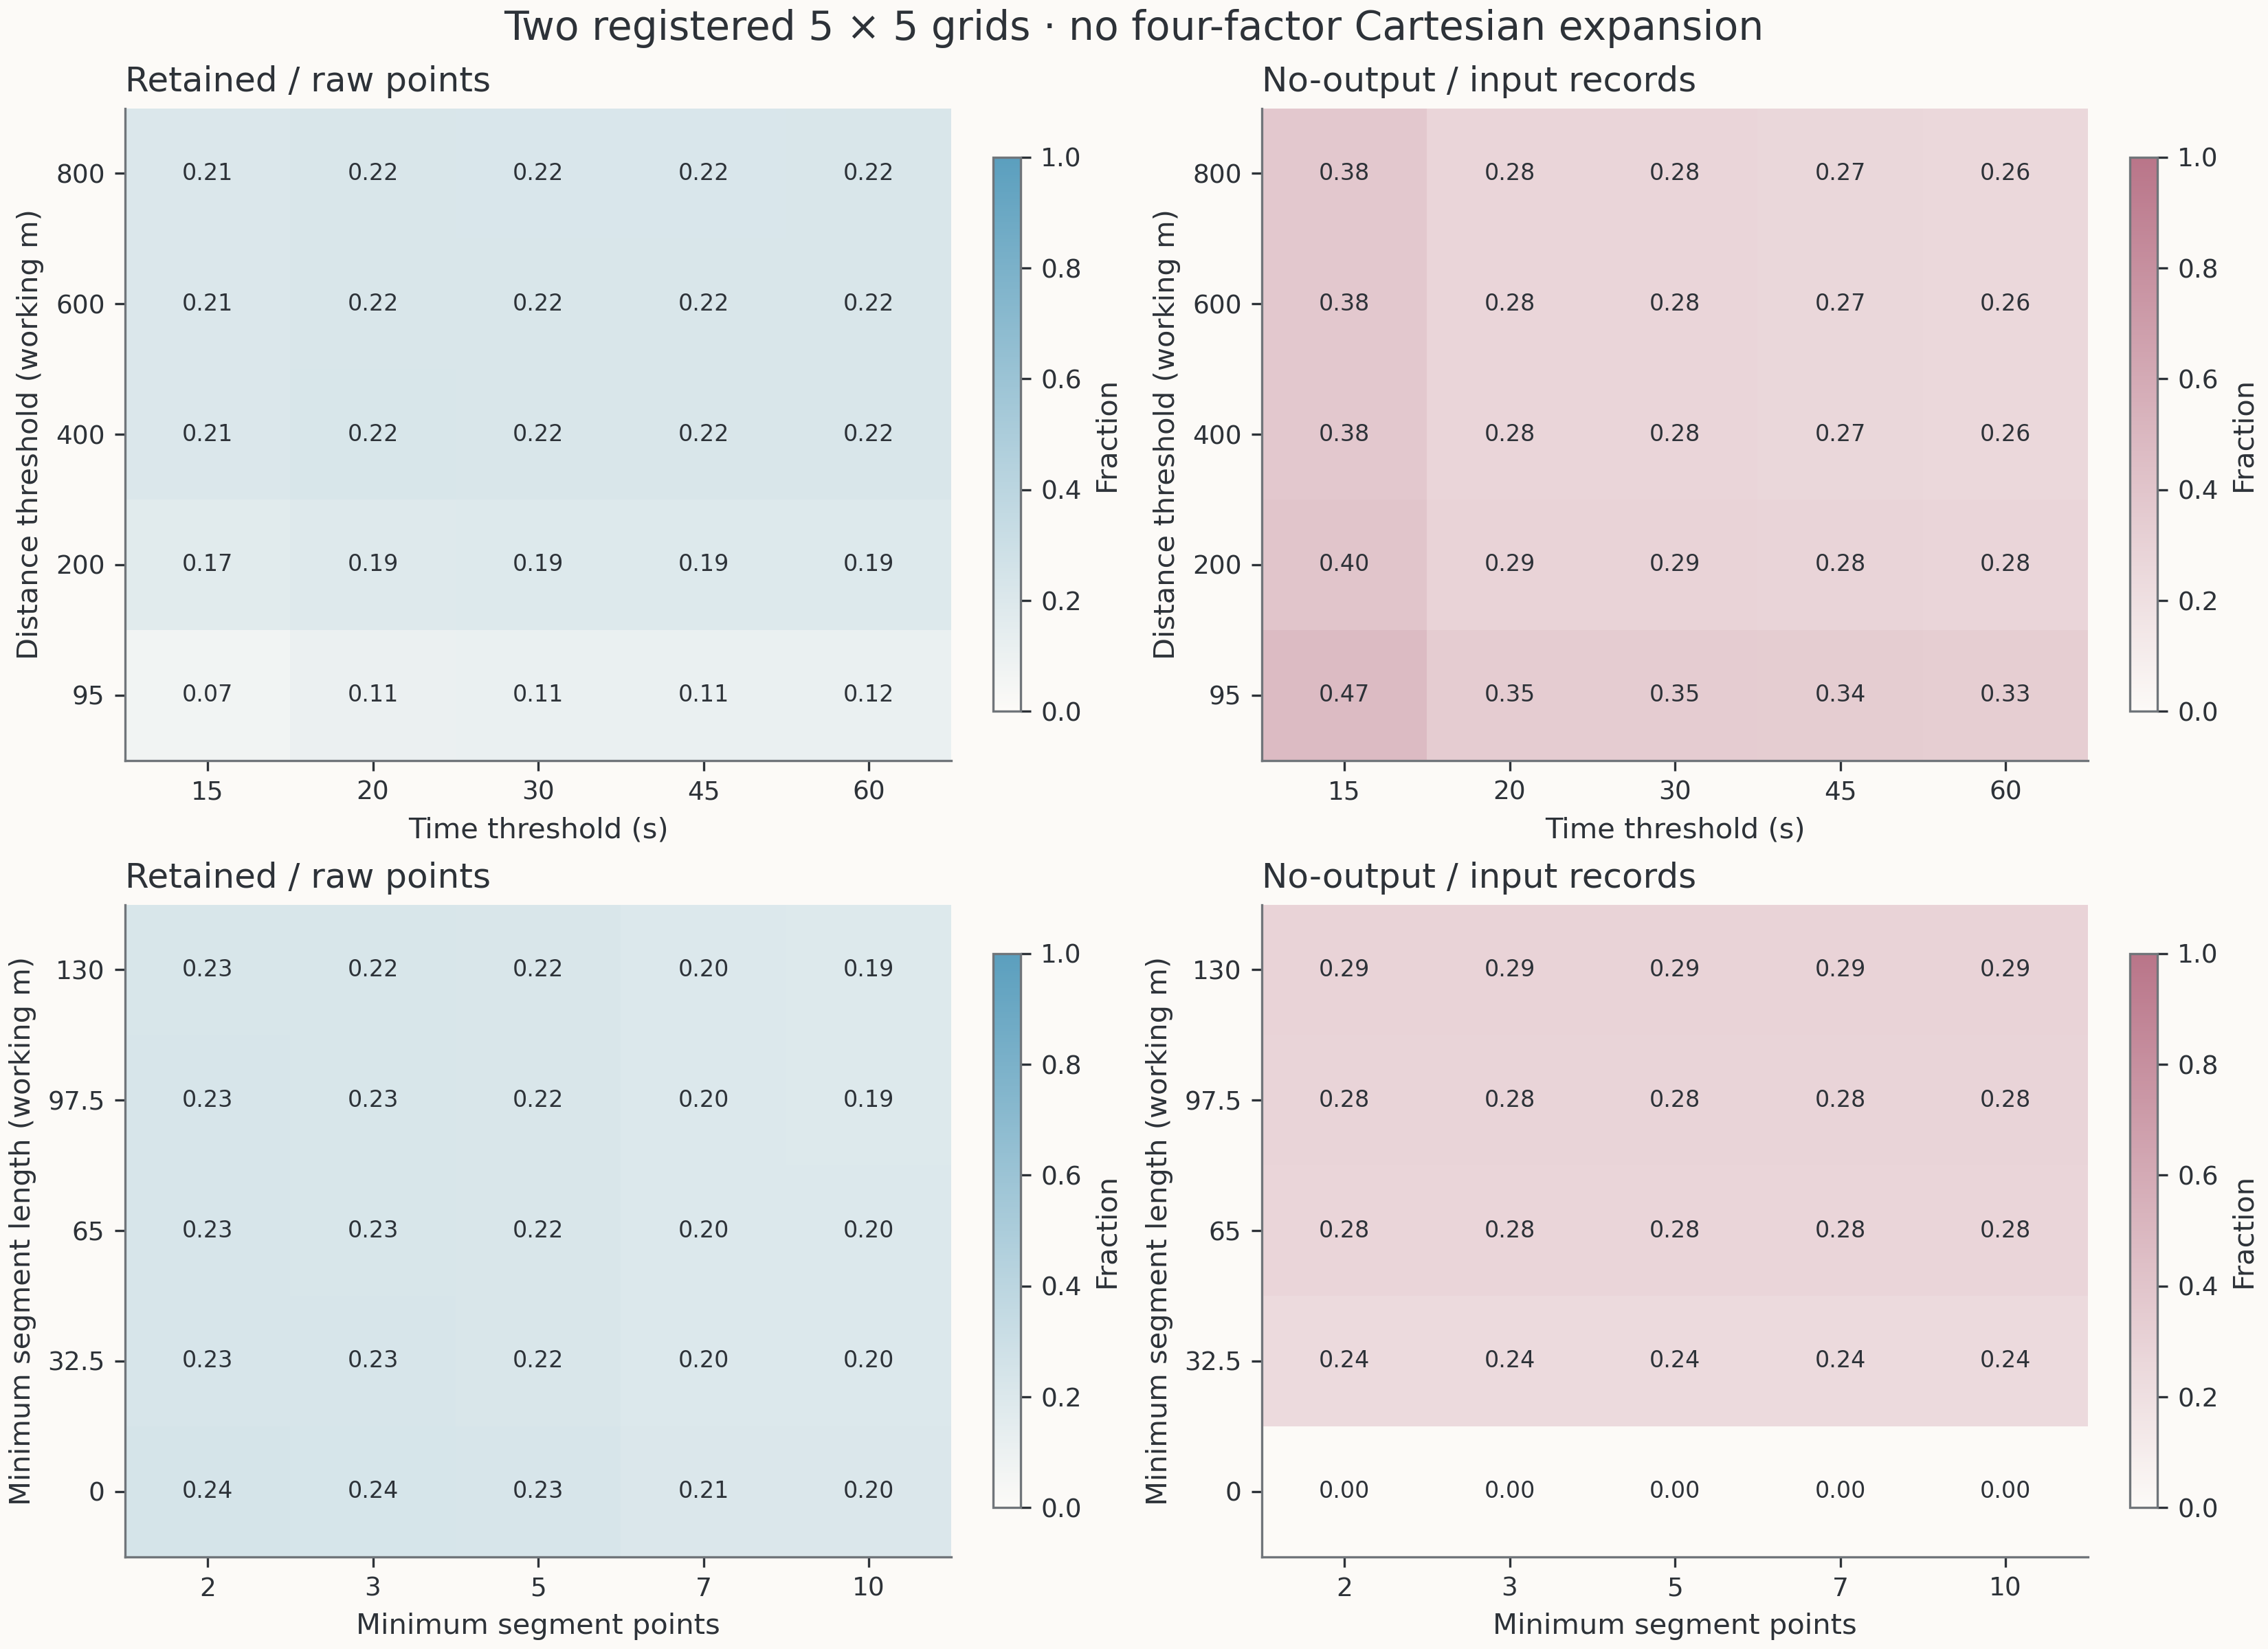

**已归档正式图：** goal2 / direction_threshold_and_neighborhood（历史解释材料）

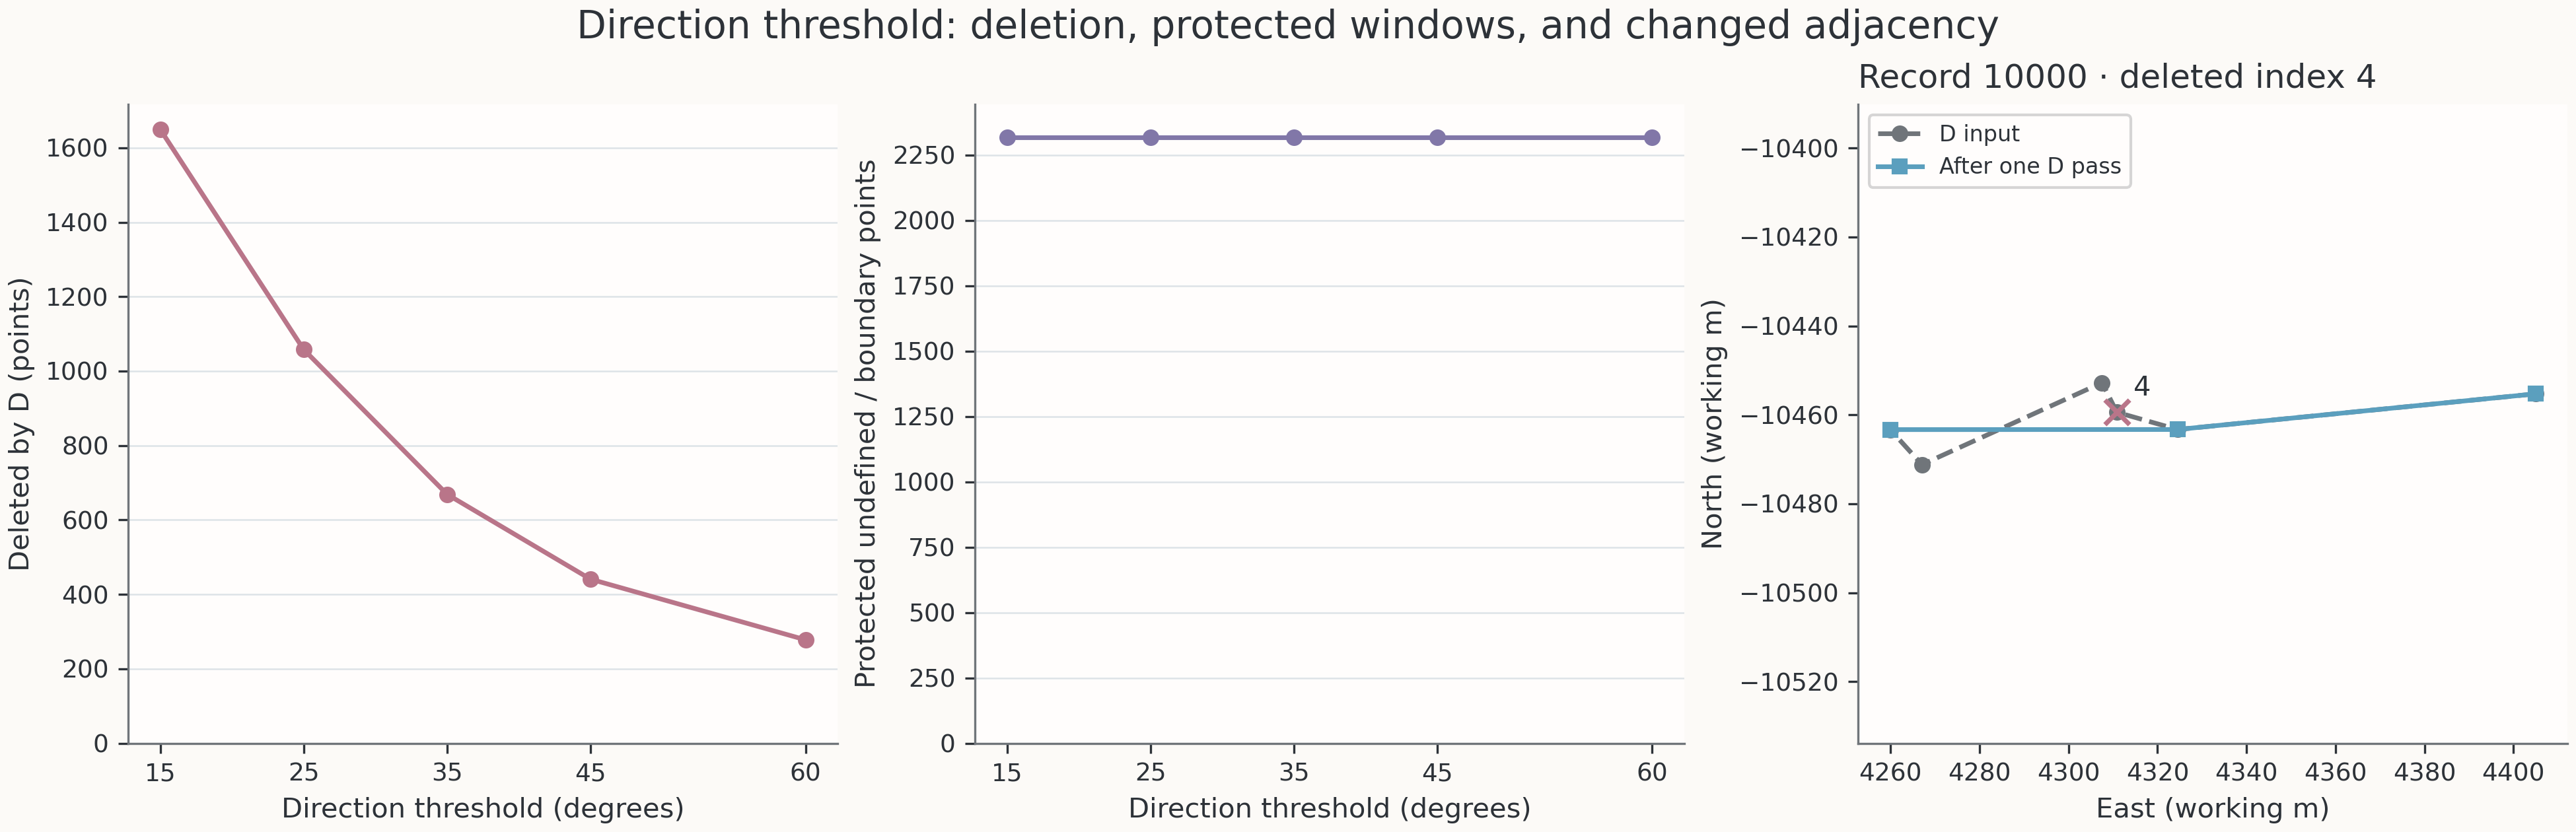

**已归档正式图：** goal2 / dp_error_compression（历史解释材料）

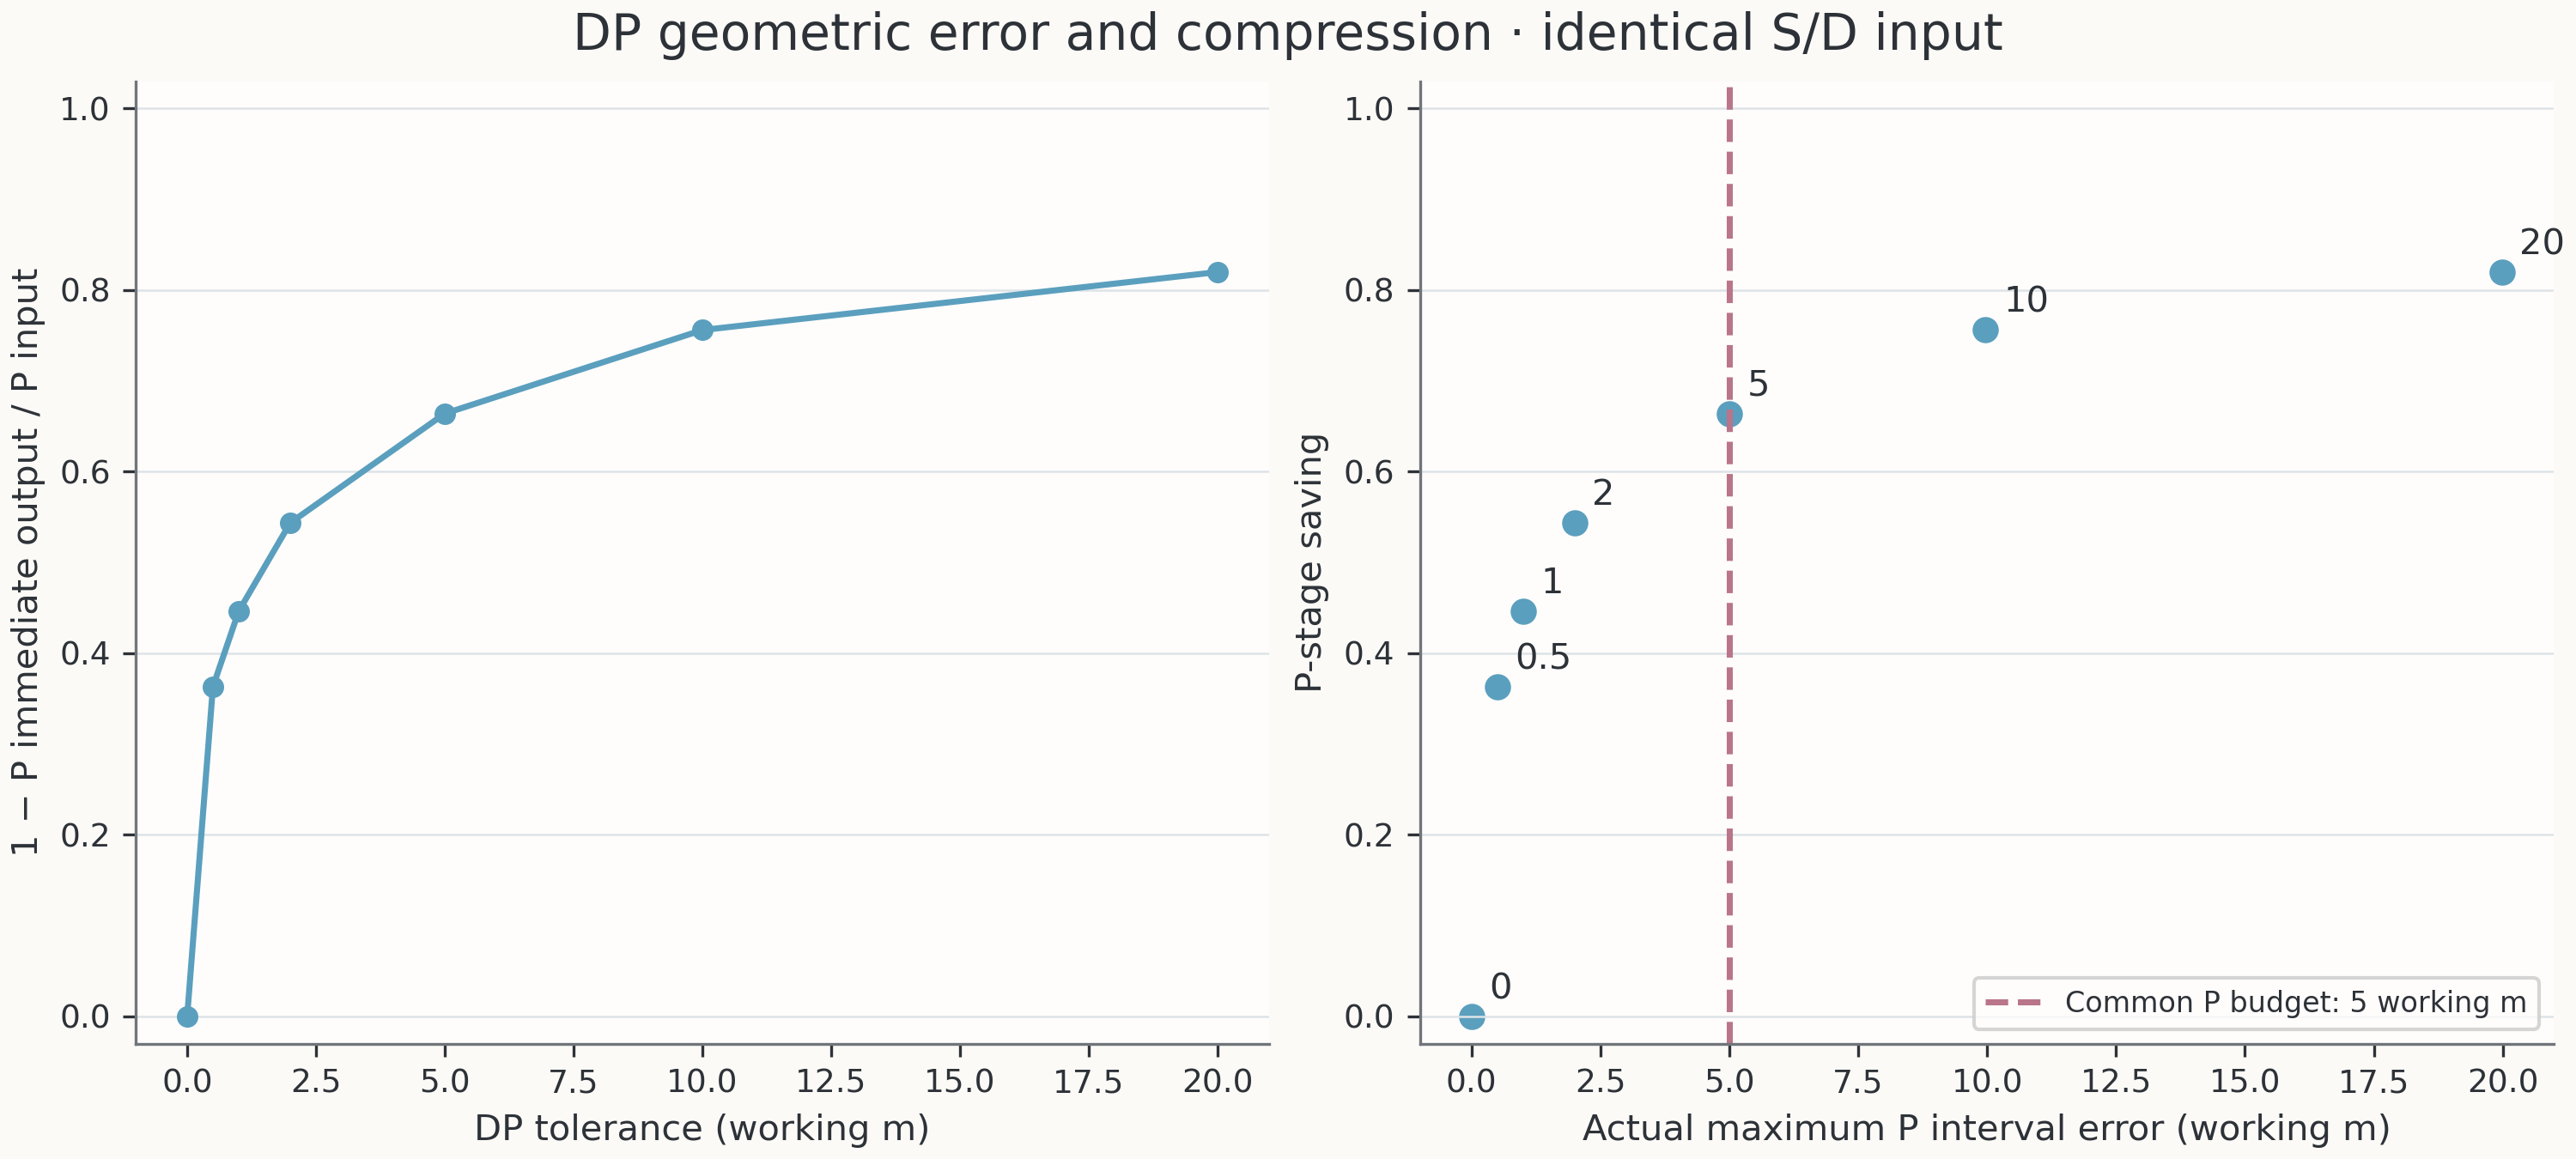

In [8]:
figure('segmentation_filter_grids')
figure('direction_threshold_and_neighborhood')
figure('dp_error_compression')

### 顺序结果与拒绝理由

六种顺序按字面执行，没有藏一个额外预分段。D先于S可能跨断点取方向邻域；P先于S可能删除断点触发点。四种危险顺序被实际拒绝。S-P-D仍有权衡，P即时误差不能冒充后续D删除后的最终保证。

order,n_records,safety_failure_records,raw_break_crossings,direction_windows_across_raw_breaks,p_removed_raw_break_trigger_points,research_status
S-D-P,120,0,0,0,0,NO_DEMONSTRATED_GAIN
S-P-D,120,0,0,0,0,TRADEOFF
D-S-P,120,46,1,612,1,REJECTED_BY_CONSTRAINT
D-P-S,120,87,1,612,188,REJECTED_BY_CONSTRAINT
P-S-D,120,87,0,0,193,REJECTED_BY_CONSTRAINT
P-D-S,120,87,1,453,193,REJECTED_BY_CONSTRAINT


**已归档正式图：** goal2 / order_protection_and_neighborhoods（历史解释材料）

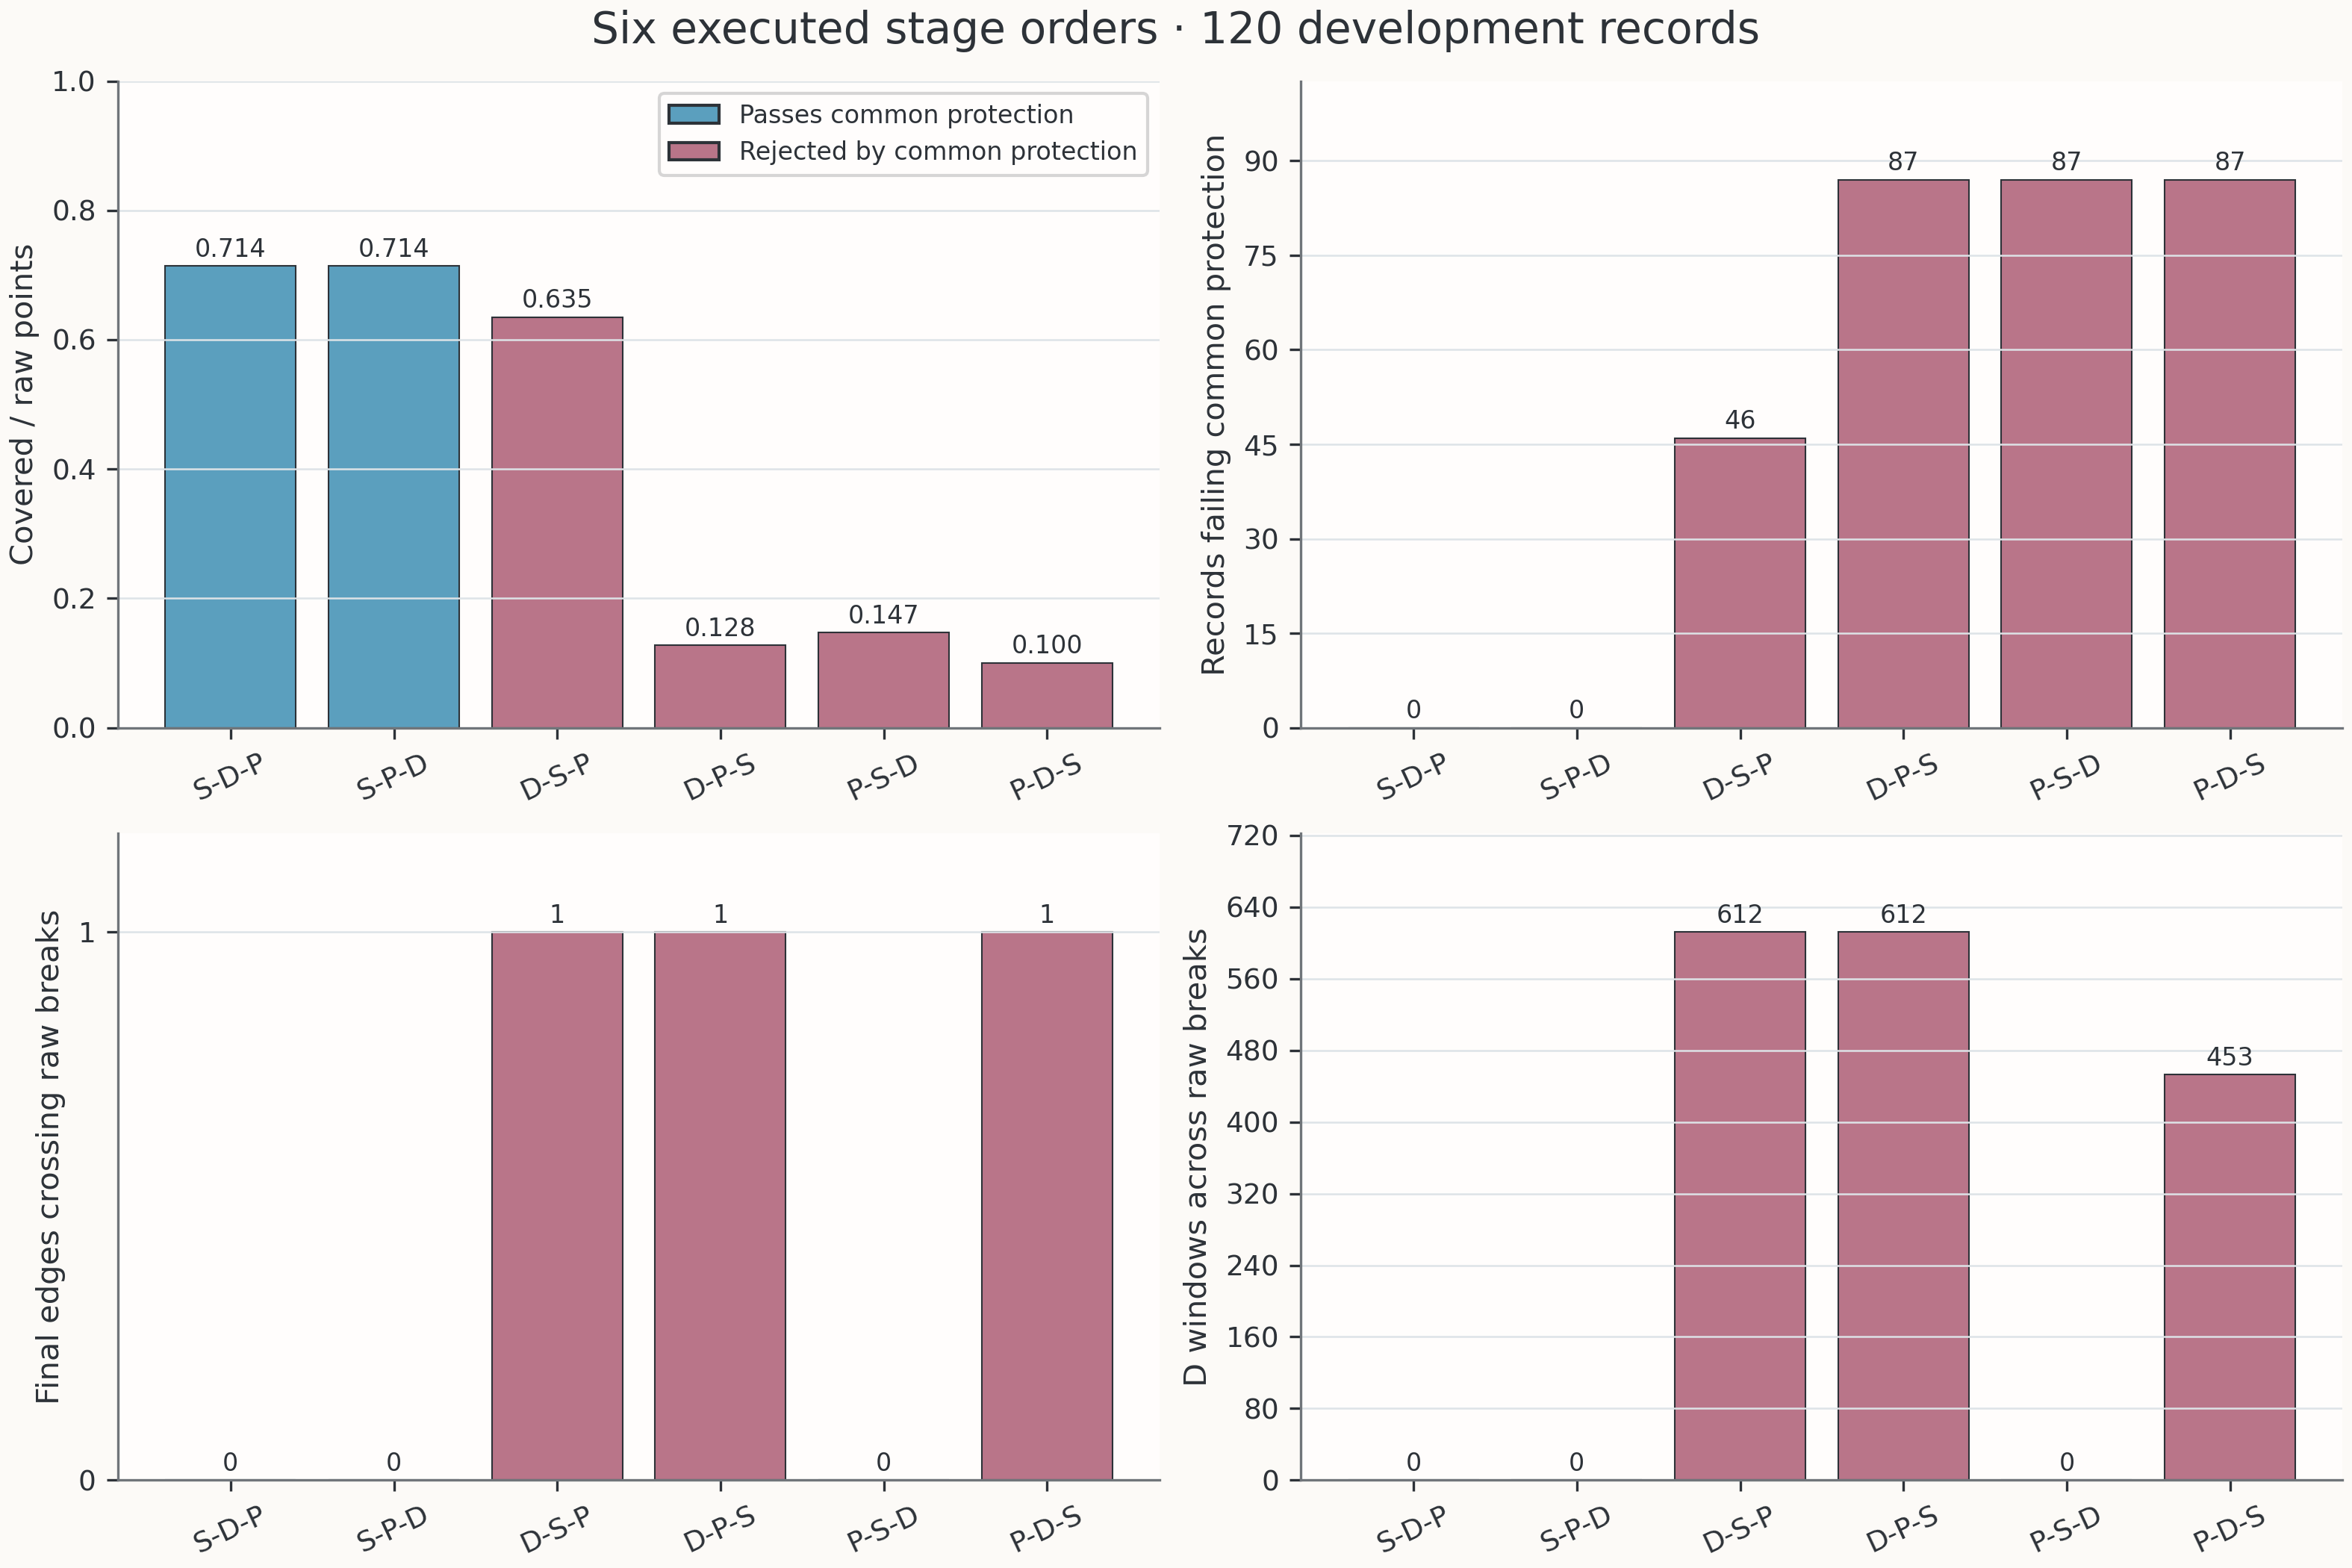

In [9]:
show([r for r in stage['orders'] if r['partition']=='DEVELOPMENT'],['order','n_records','safety_failure_records','raw_break_crossings','direction_windows_across_raw_breaks','p_removed_raw_break_trigger_points','research_status'])
figure('order_protection_and_neighborhoods')

## 6. 真实 AI 批判与至少一组可复验反例

记录7764的合法建议提出额外空间分段。实际同一122点覆盖下共同最大误差40.215→69.145工作米，而自身P误差同为4.826；因此未采用。另一建议失去11个参考覆盖点，此时基线完整集合误差不可用，不能把null写成“数值变差”。完整原始引文与response哈希如下。构造标签只适用于已知答案，不迁移为真实噪声真值。

id,record,original_reason,parameters,locked_output,source_response
AI-DEV-01,7764,"Direction 60 alone left common maximum error unchanged. Test additional spatial splits with relaxed segment filters; existing raw breaks remain separated, while coverage and fidelity require evaluation.","{""dt"": 30, ""distance"": 200, ""min_points"": 2, ""min_length"": 0, ""direction"": 60, ""dp"": 5}",False,"{""path"": ""task1/evidence/goal2/runs/g2-development-modes-02/modes/DEVELOPMENT-llm+memory+search-e1-b2/round2_call/attempt01/response.json"", ""sha256"": ""fe36cab28325d549ba8118e21e59d53363b7147f4da77b45346d36404e58db98""}"
AI-DEV-02,7764,Test a stronger spatial split threshold after the direction-only trial tied protected maximum error. Preserve raw break separation; short-window coverage remains uncertain.,"{""dt"": 30, ""distance"": 95, ""min_points"": 2, ""min_length"": 0, ""direction"": 60, ""dp"": 5}",False,"{""path"": ""task1/evidence/goal2/runs/g2-development-modes-02/modes/DEVELOPMENT-llm+memory+search-e1-b2/round2_call/attempt01/response.json"", ""sha256"": ""fe36cab28325d549ba8118e21e59d53363b7147f4da77b45346d36404e58db98""}"
AI-DEV-03,7764,"Additional spatial splits degraded protected geometry. Restore reference segmentation and test tighter DP with direction 60; removals remain 20 versus reference 31, while common error is uncertain.","{""dt"": 30, ""distance"": 400, ""min_points"": 5, ""min_length"": 65, ""direction"": 60, ""dp"": 2}",False,"{""path"": ""task1/evidence/goal2/runs/g2-development-modes-02/modes/DEVELOPMENT-llm+memory+search-e1-b2/round3_call/attempt01/response.json"", ""sha256"": ""9c635a83691ac1527de98b8dcf0212a57adf6b2410aa7bba07a087c06c388d82""}"
AI-DEV-04,7764,Direction 60 retained the reference maximum error at DP 5. Test its interaction with DP 2; direction removals remain 20 versus 31.,"{""dt"": 30, ""distance"": 400, ""min_points"": 5, ""min_length"": 65, ""direction"": 60, ""dp"": 2}",False,"{""path"": ""task1/evidence/goal2/runs/g2-development-modes-02/modes/DEVELOPMENT-llm+search-e1-b2/round3_call/attempt01/response.json"", ""sha256"": ""8ede213891e25566733c0627f53fbca6037e145361d321127e0238902fb9e517""}"
AI-DEV-05,10232,Direction 60 improved common maximum error and removed 10 versus reference 32. Test tighter DP while preserving that verified direction stage.,"{""dt"": 30, ""distance"": 400, ""min_points"": 5, ""min_length"": 65, ""direction"": 60, ""dp"": 2}",False,"{""path"": ""task1/evidence/goal2/runs/g2-development-modes-02/modes/DEVELOPMENT-llm+memory+search-e1-b2/round2_call/attempt01/response.json"", ""sha256"": ""fe36cab28325d549ba8118e21e59d53363b7147f4da77b45346d36404e58db98""}"
AI-DEV-06,10232,Isolate the direction threshold's effect on protected fidelity; the card cannot establish an error change.,"{""dt"": 30, ""distance"": 400, ""min_points"": 5, ""min_length"": 65, ""direction"": 60, ""dp"": 5}",False,"{""path"": ""task1/evidence/goal2/runs/g2-development-modes-02/modes/DEVELOPMENT-llm+memory+search-e1-b2/round1_call/attempt01/response.json"", ""sha256"": ""6207cfd3ccfe3cee4b0cf7f12c807cf63a8f0175c9c77bcf3b1dc22c7059ce66""}"


当前内核已知答案处理链实际复算： 19
完整构造与独立检查入口：task1/evidence/goal2/counterexamples/formal-02/


**已归档正式图：** goal2 / synthetic_metric_counterexamples（历史解释材料）

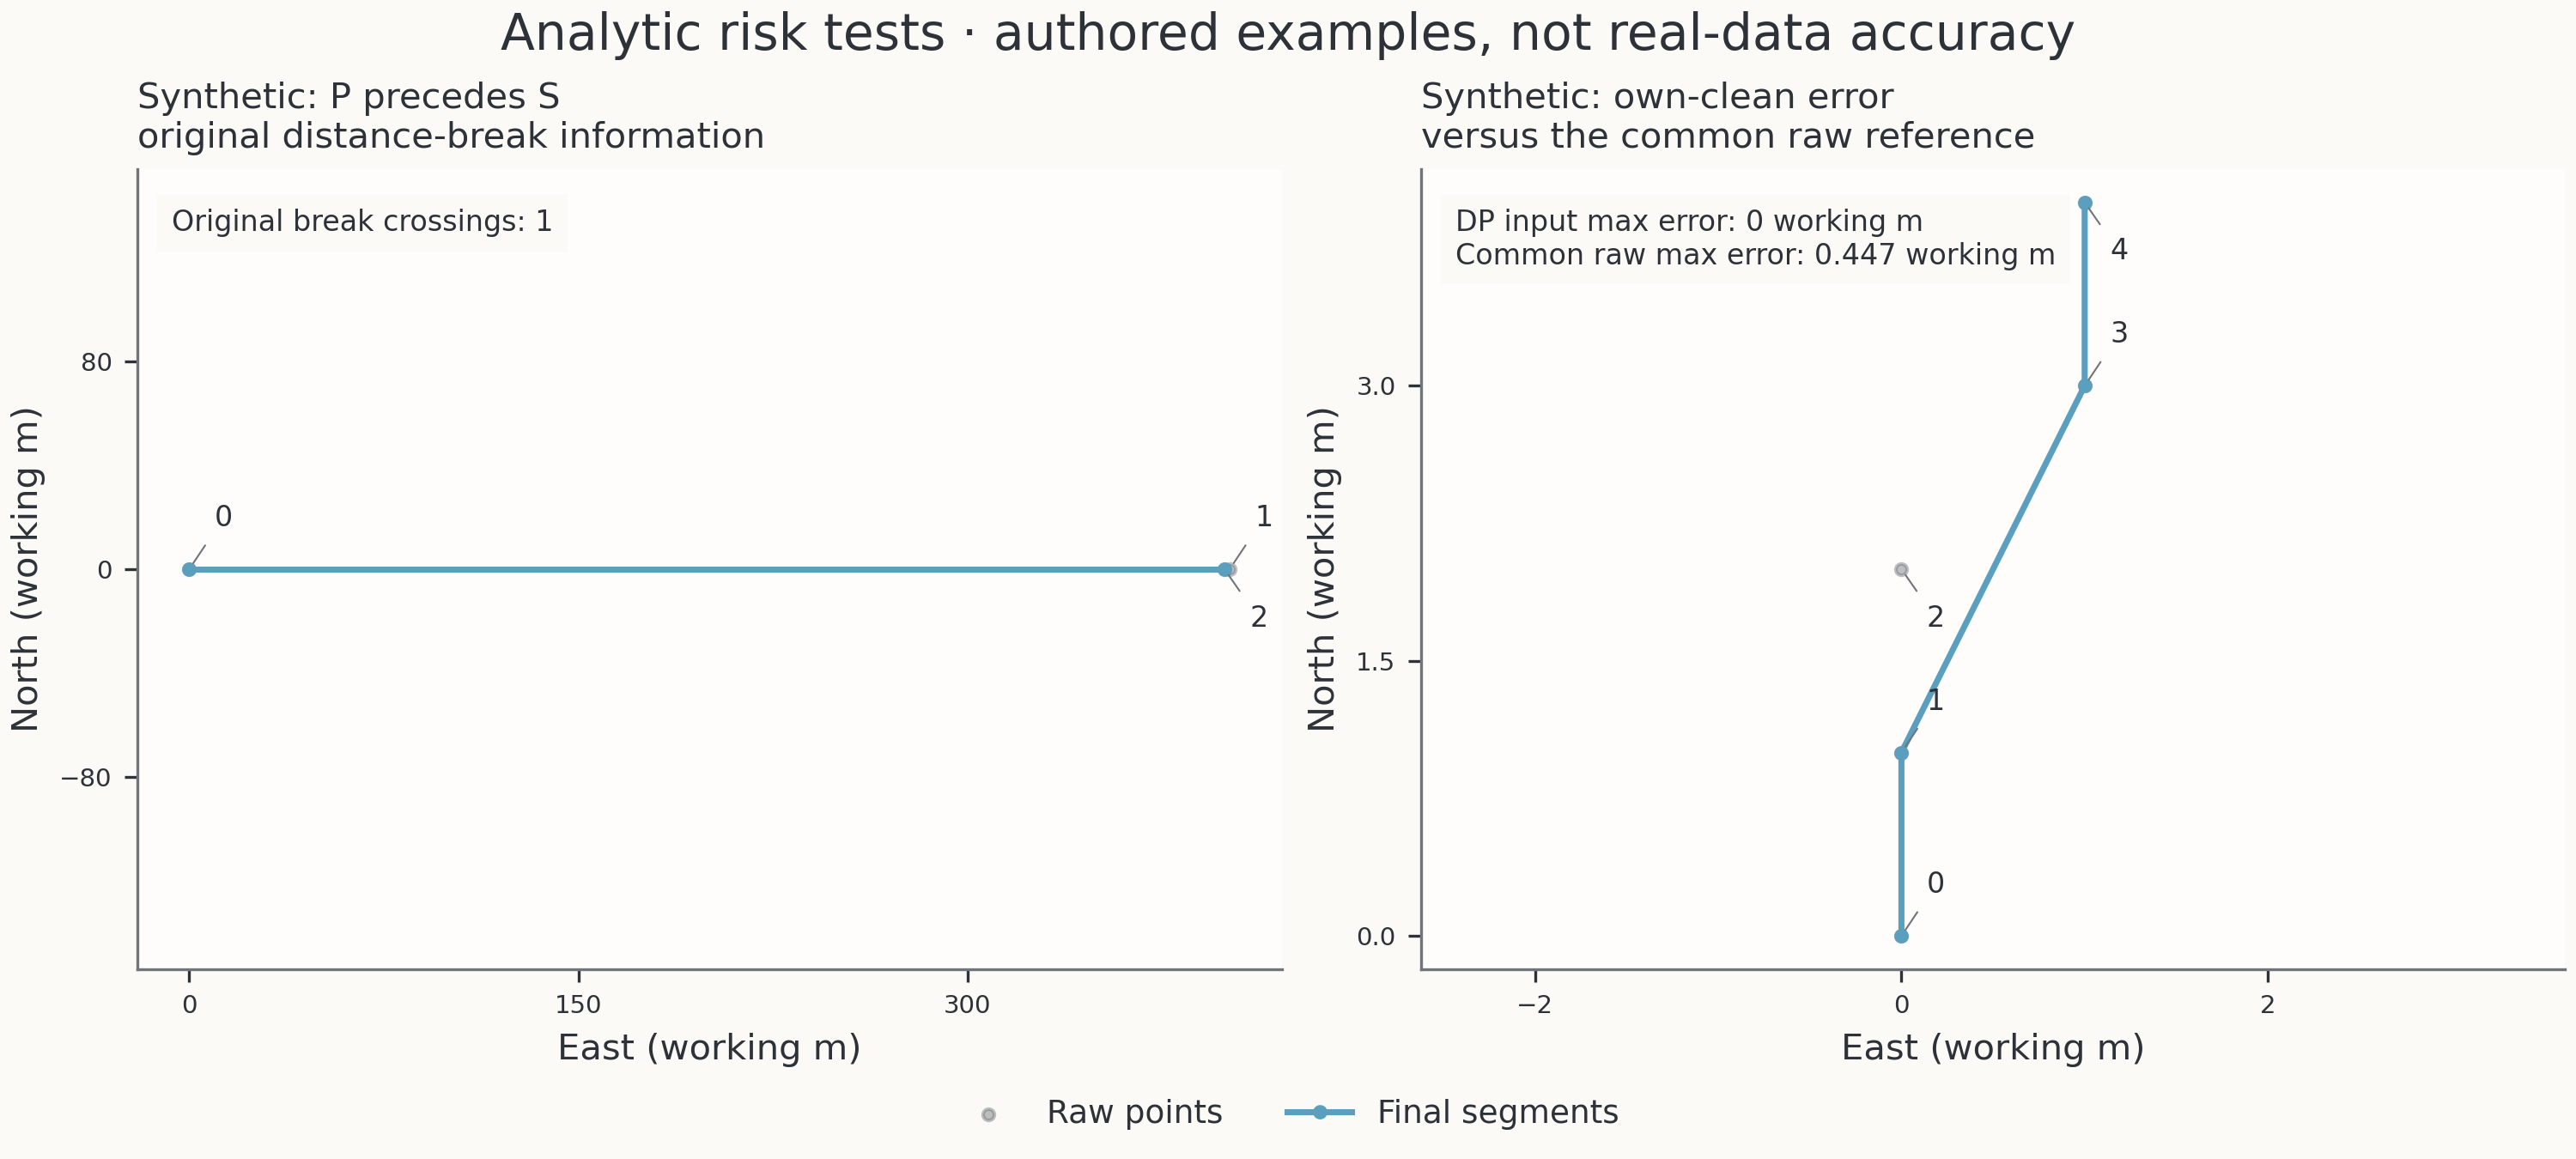

In [10]:
ai=read_json(G2/'a_epoch02/actual_ai_critique/actual_ai_critique.json')
show([{'id':x['citation_id'],'record':x['record_id'],'original_reason':x['verbatim_model_reason'],
       'parameters':x['candidate_parameters'],'locked_output':x['proposal_became_locked_output'],
       'source_response':x['raw_response']} for x in ai['actual_ai_citations']],limit=6)
synthetic=read_json(G2/'counterexamples/formal-02/synthetic_cases.json')
show([{'case':c['case_id'],'before_after':c['before_after'],'known_answer_checks':len(c['known_answer_checks'])}
      for c in synthetic['cases']],limit=6)
# 从完整已保存构造输入重新执行19条处理链，比较真实输出；不是新独立实验。
synthetic_recomputations=0
for case in synthetic['cases']:
    for name,payload in case['executions'].items():
        expected=payload['output']
        rebuilt=run_record(expected['source_record'],expected['parameters'],expected['order'],
                           contract_hash=expected['contract_hash'],provenance=expected['provenance'])
        assert object_hash(rebuilt)==object_hash(expected),(case['case_id'],name)
        synthetic_recomputations+=1
assert synthetic_recomputations==19
print('当前内核已知答案处理链实际复算：',synthetic_recomputations)
print('完整构造与独立检查入口：task1/evidence/goal2/counterexamples/formal-02/')
figure('synthetic_metric_counterexamples')

## 7. 冻结策略下全量生产：真实复算全部原始记录

最终确认在冻结规则下已经完成，本单元复算冻结生产策略与R0；若完全相同只复用一次。生产包含全部分区，其统计描述本数据集输出，不把开发使用过的记录重新当成独立测试。每条记录和每个点终态均保留；候选失败、回退和最终输出不能混为一个通过率。

{'status': 'VERIFIED', 'mode': 'FULL_RECOMPUTE', 'new_model_calls': 0, 'raw_records': 11386, 'record_evaluations': 22772, 'actual_full_shard_hash_equality': True, 'source_sha256': '440f426ef60acde8475395d9a2dee955a2e6f9fd142cb06b9c67d549a749b334', 'raw_recomputed_plots': {'figure_count': 2, 'manifest_path': 'figures/figure_manifest.json', 'manifest_sha256': 'd73efbfa1529fcd5cc88bc1ce7830d868f4c0d24a2dd8cacd21e52f2d0c74af0', 'plot_data_sha256': '828916a8583983f4791c97bce8c7eab4f39d069e2f80d6e011cdae79b1cb2765', 'lineage': 'newly recomputed raw results; historical targets used only for equality checks'}}


strategy,n_records,n_input,n_filtered,n_direction_removed,n_dp_removed,n_final,common_covered_points,n_no_output_records,raw_break_crossings,dp_max_error
R0,11386,1173410,501511,36056,435373,200470,671899,4859,0,4.999963549117563
S0,11386,1173410,1199,39732,911330,221149,1172211,0,0,4.999963549117563


strategy,parameters,order,conditional_rule
R0,"{""dt"": 30, ""distance"": 400, ""min_points"": 5, ""min_length"": 65, ""direction"": 35, ""dp"": 5}",S-D-P,不可用（见相应原因）
S0,"{""dt"": 30, ""distance"": 400, ""min_points"": 2, ""min_length"": 0, ""direction"": 35, ""dp"": 5}",S-D-P,不可用（见相应原因）


最终确认（历史冻结执行，与全量统计分开）： 600 条。


全量分片字节哈希重算一致： True


**本次 FULL 从 raw 重新计算并绘制：** recomputed_point_fates

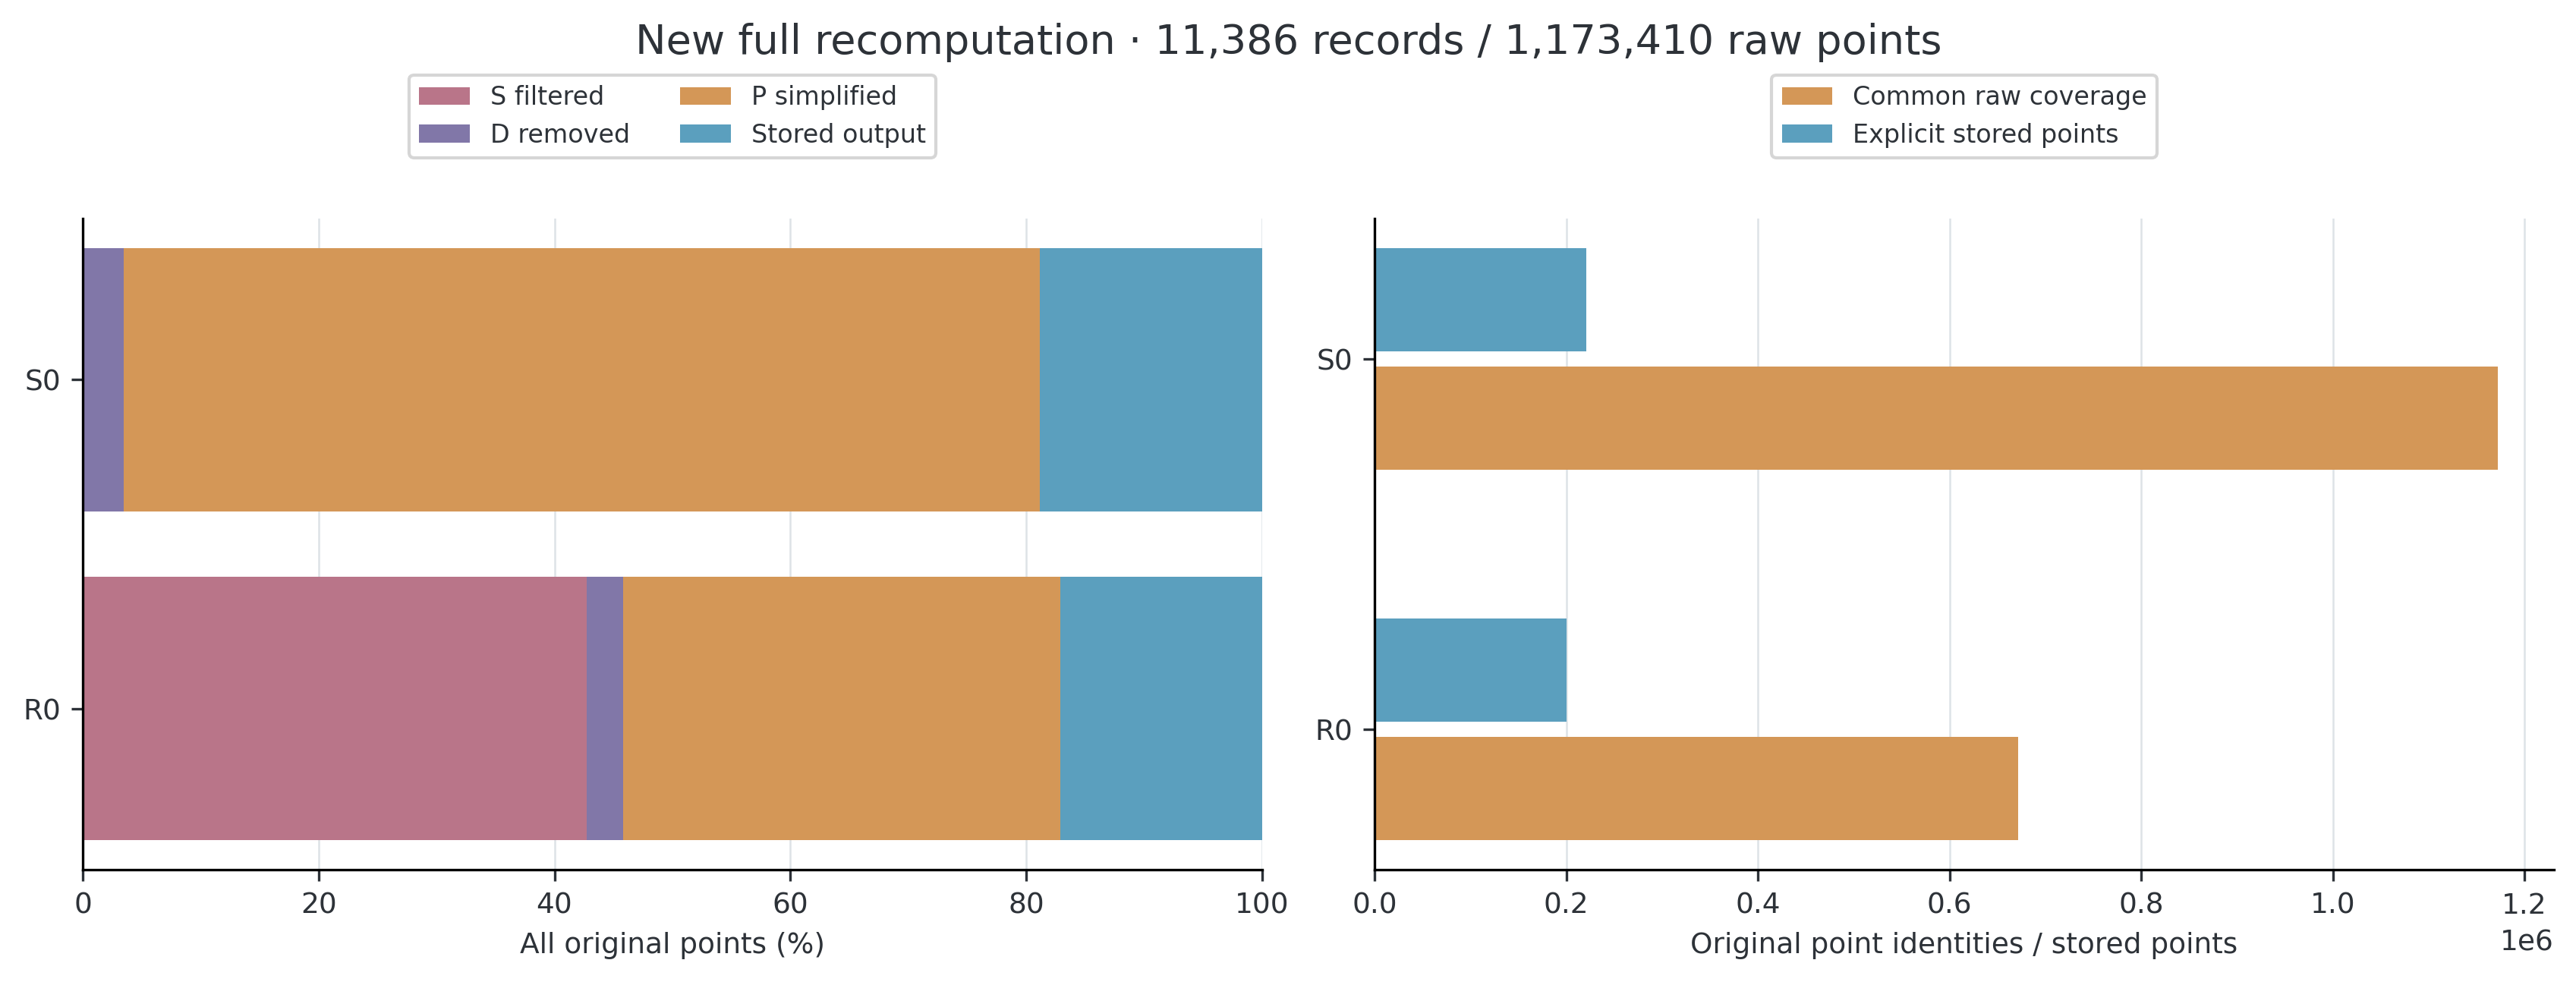

**本次 FULL 从 raw 重新计算并绘制：** recomputed_trajectory_case

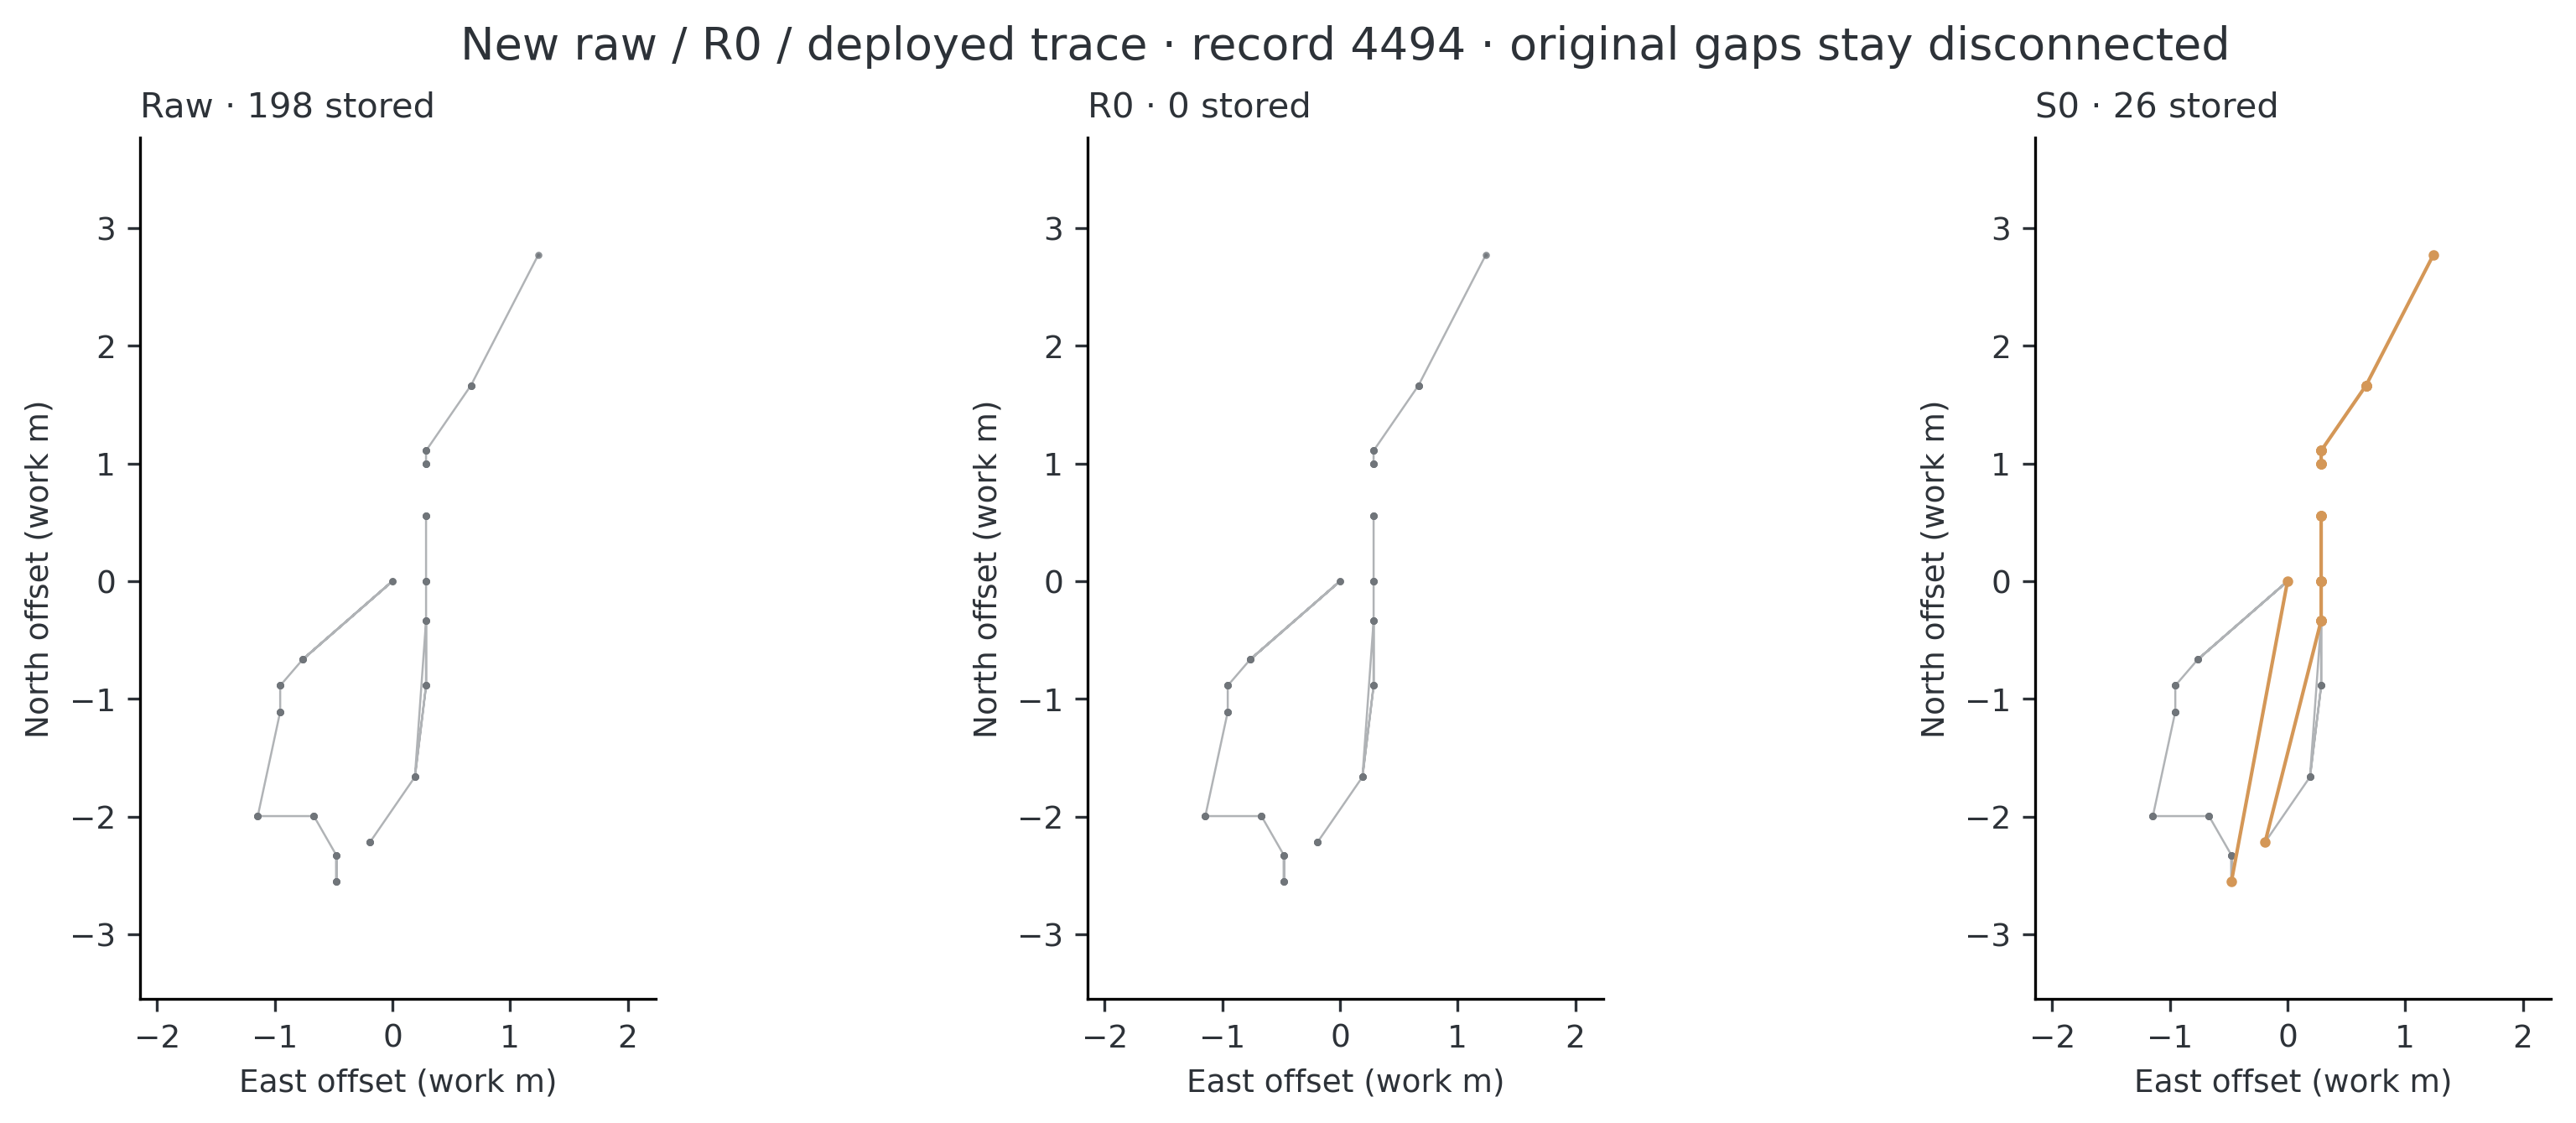

以下为已核验 G3 阶段归档图；与上方本次 raw 复算重绘图分开。


**已归档正式图：** goal3 / development_candidates（历史解释材料）

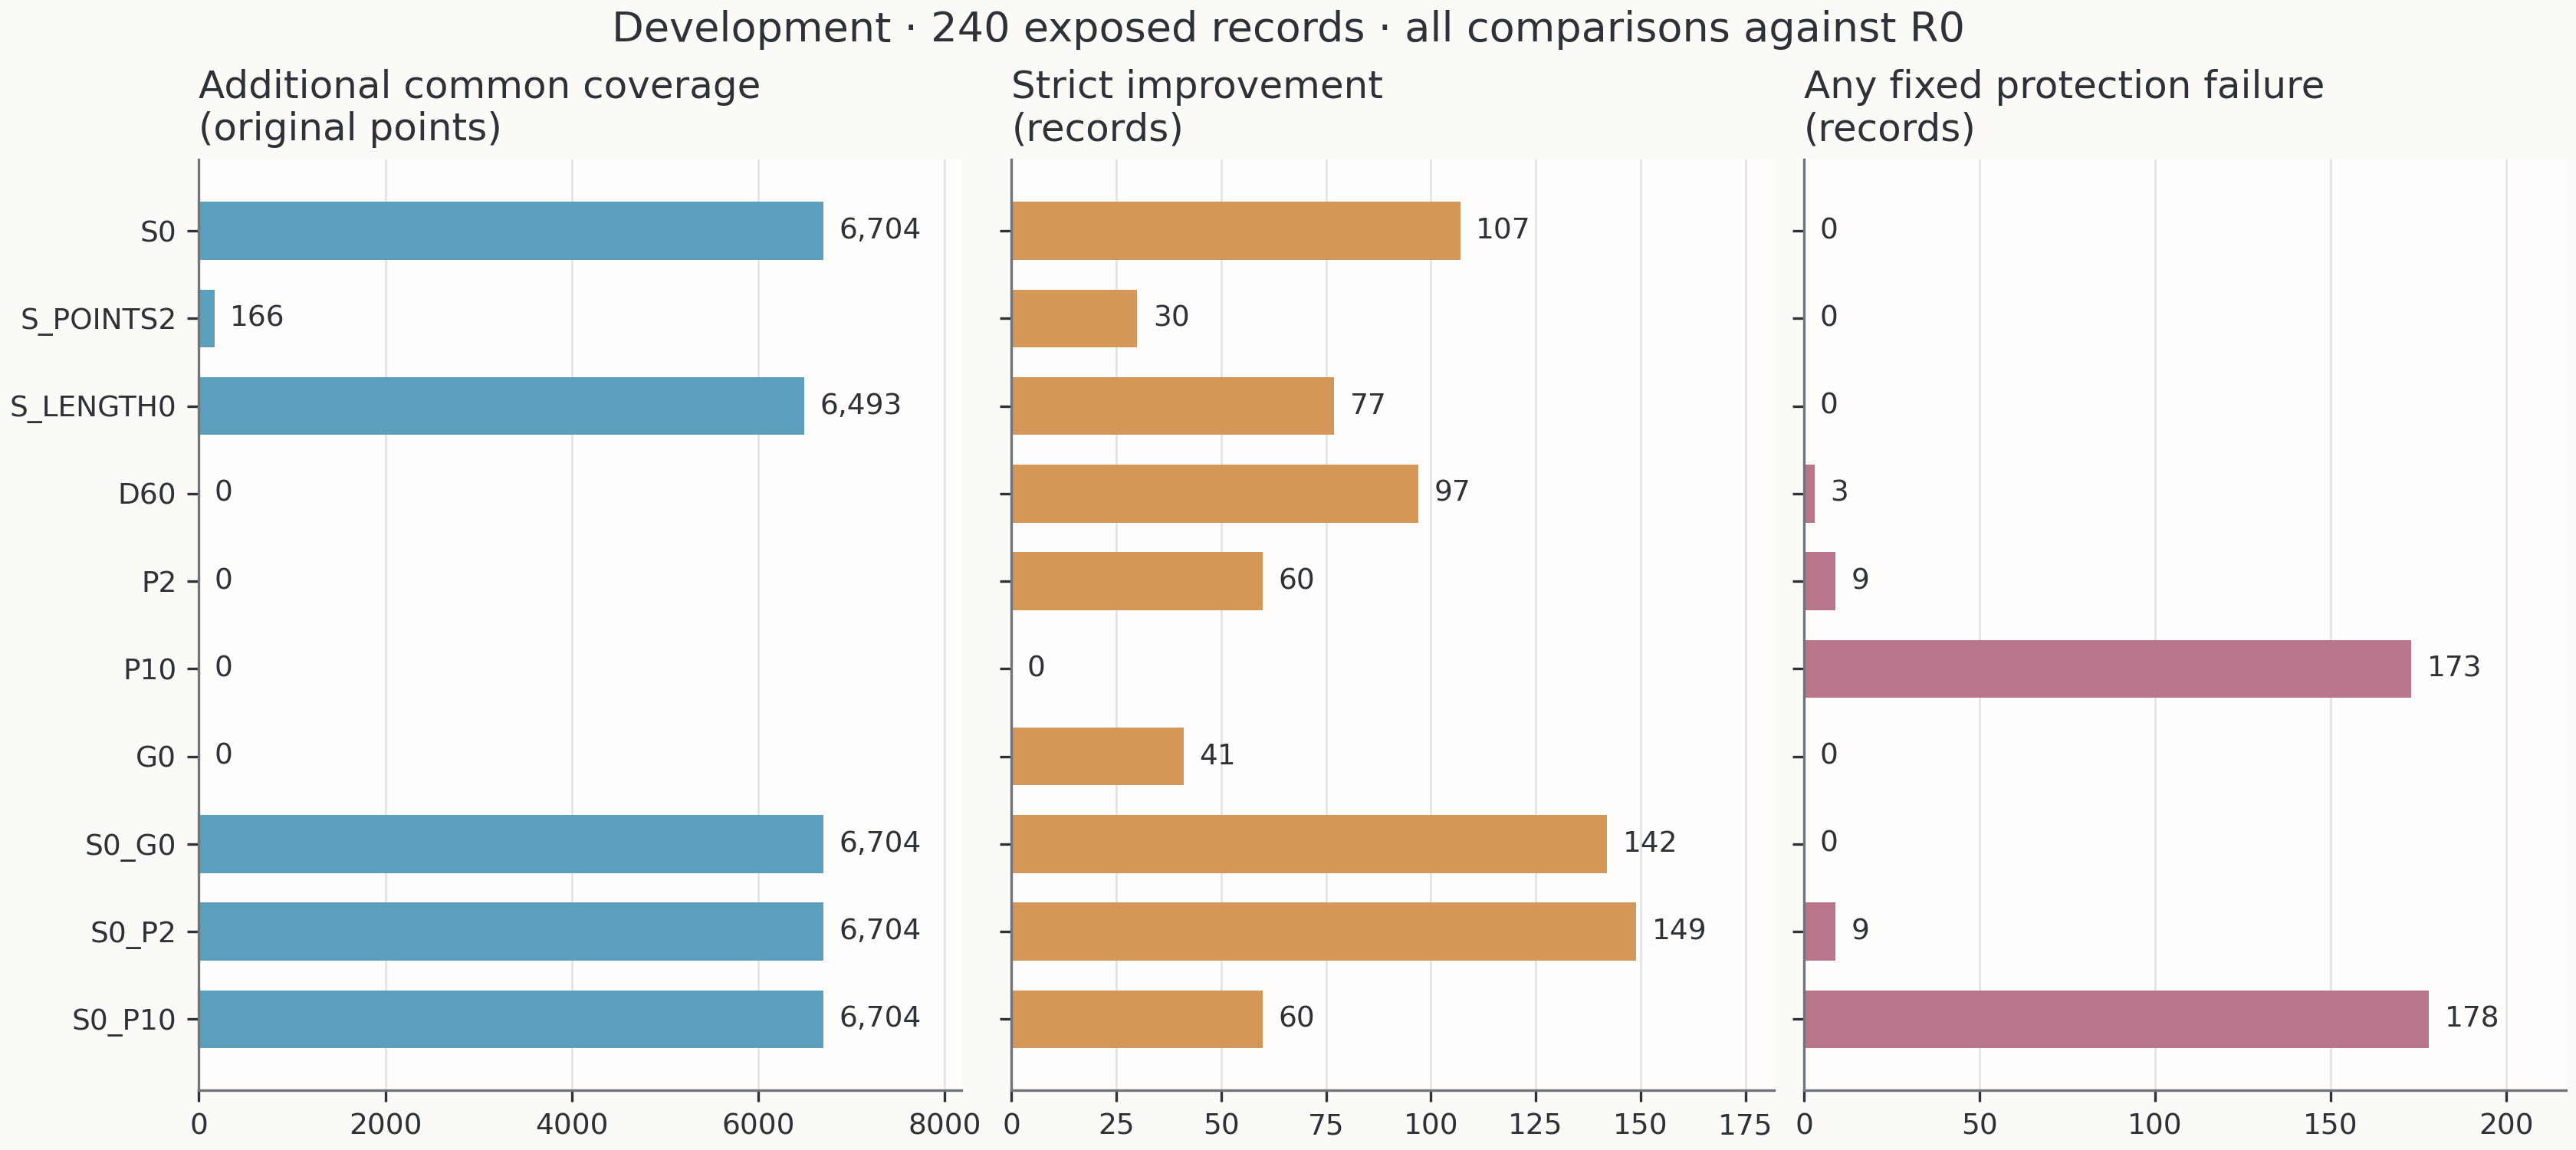

**已归档正式图：** goal3 / incumbent_decision_path（历史解释材料）

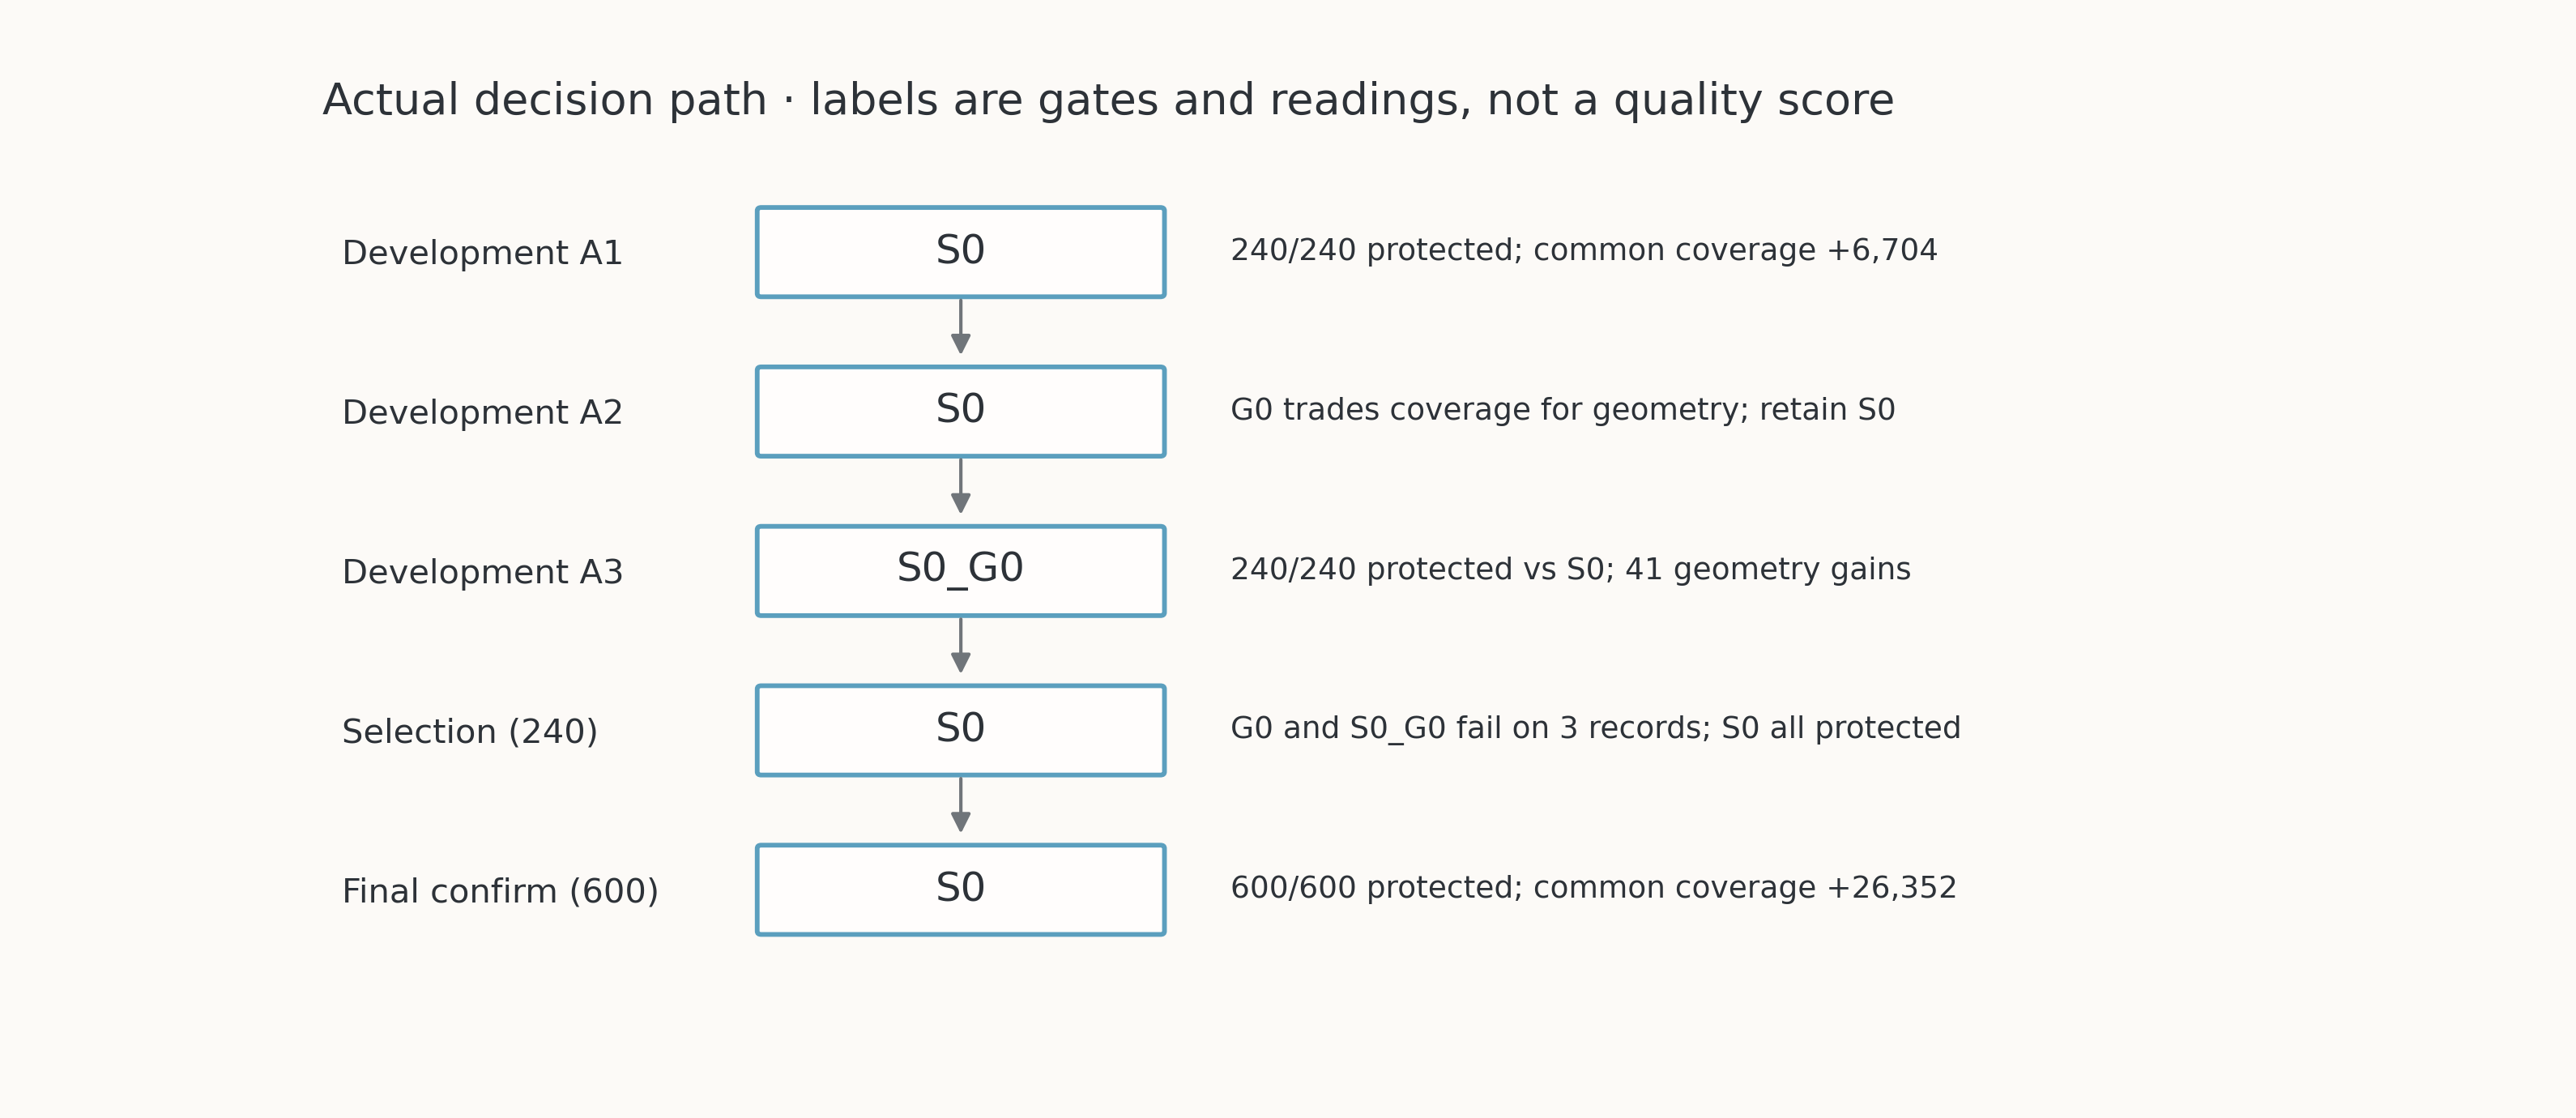

**已归档正式图：** goal3 / selection_tradeoffs（历史解释材料）

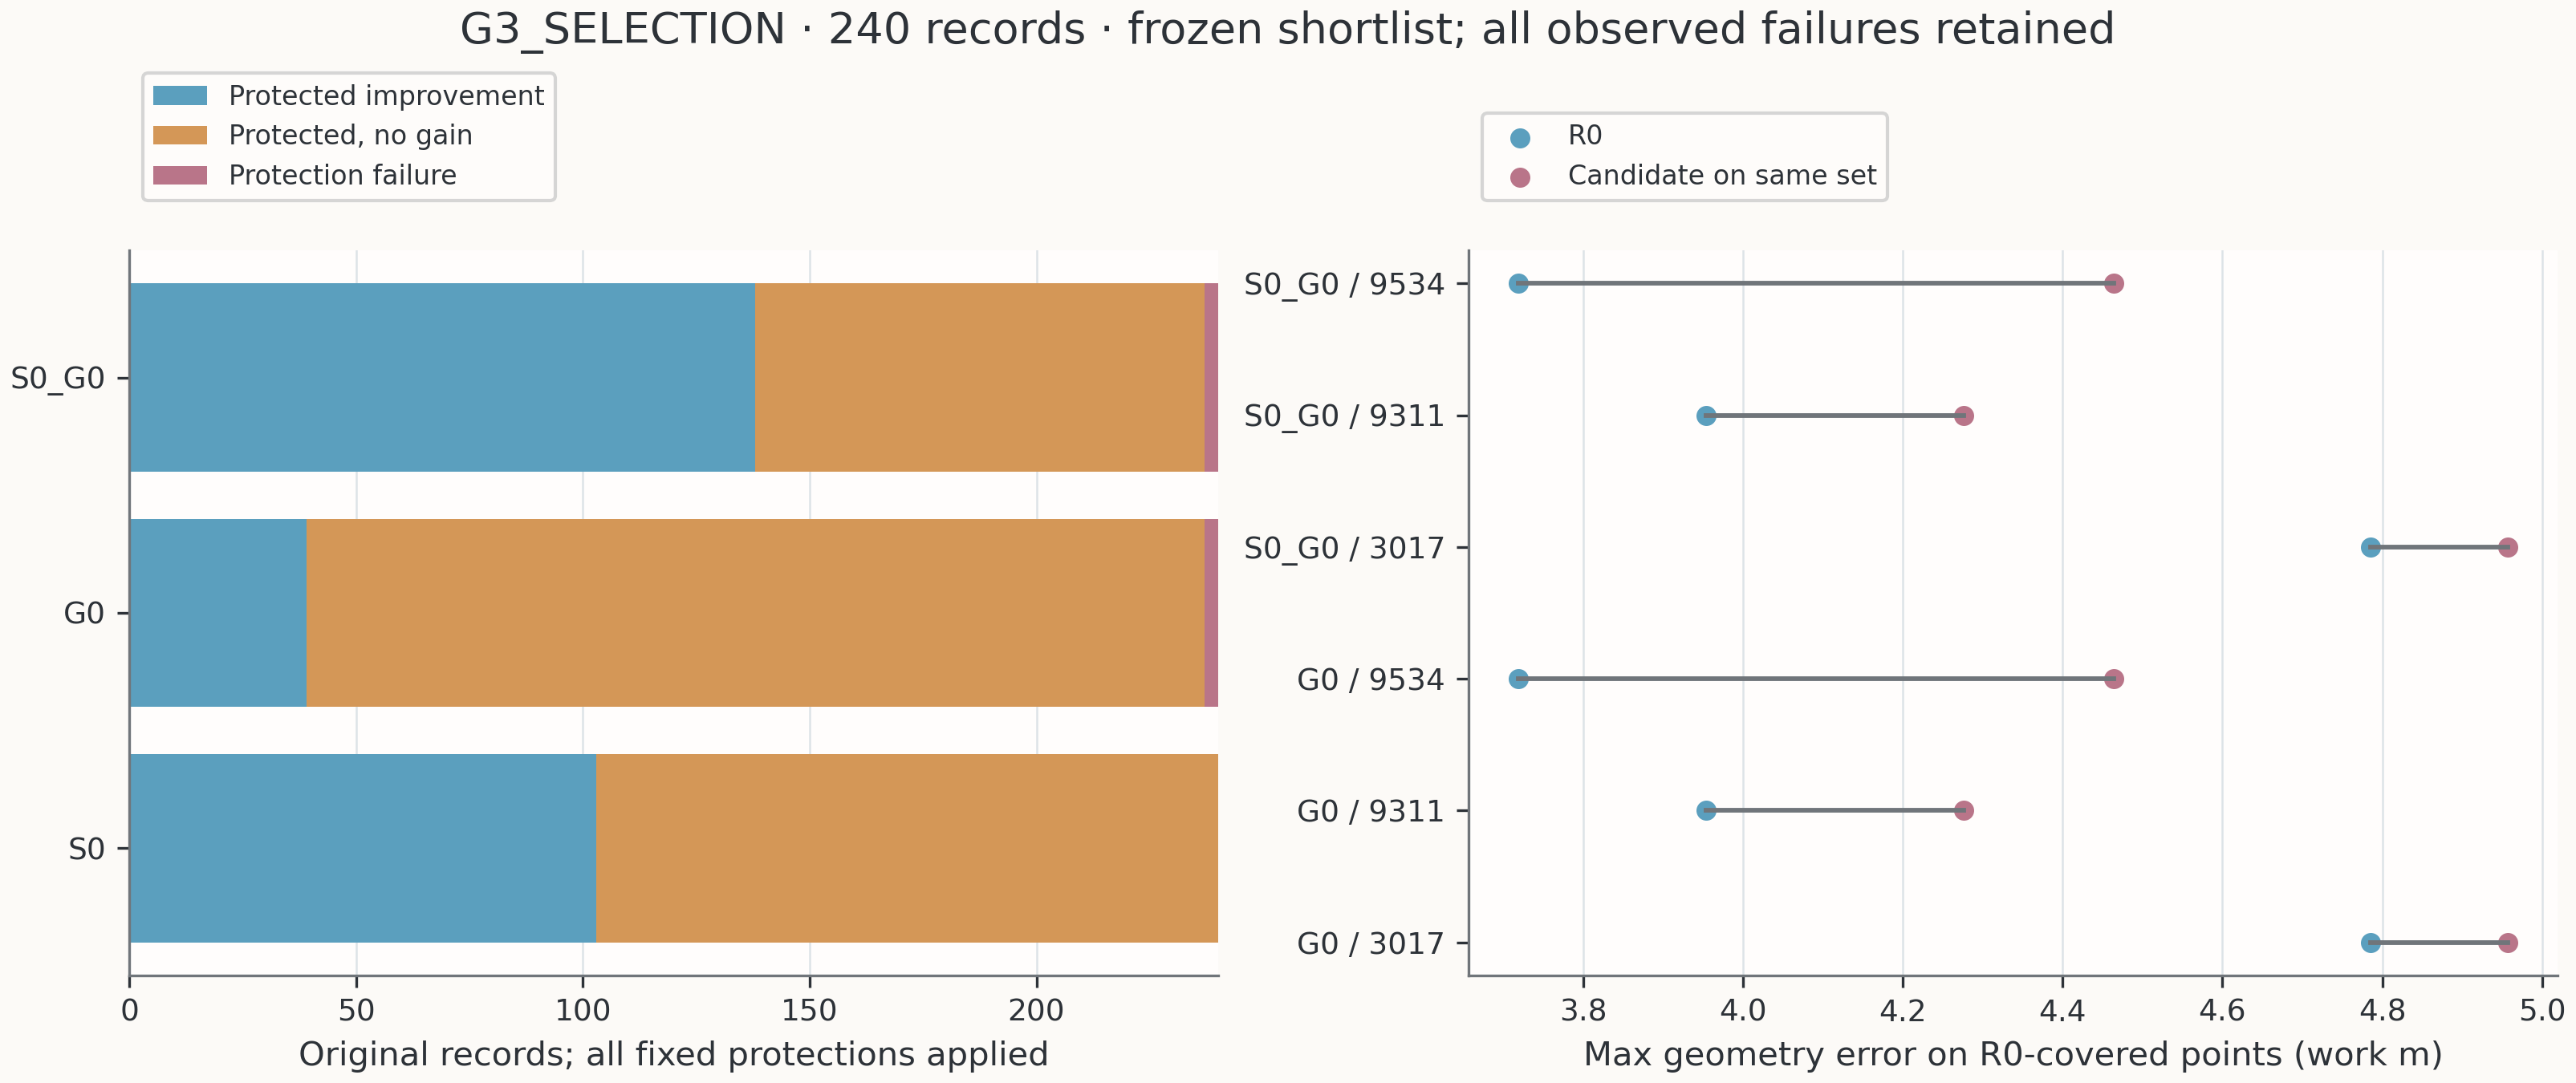

**已归档正式图：** goal3 / final_confirmation_pairs（历史解释材料）

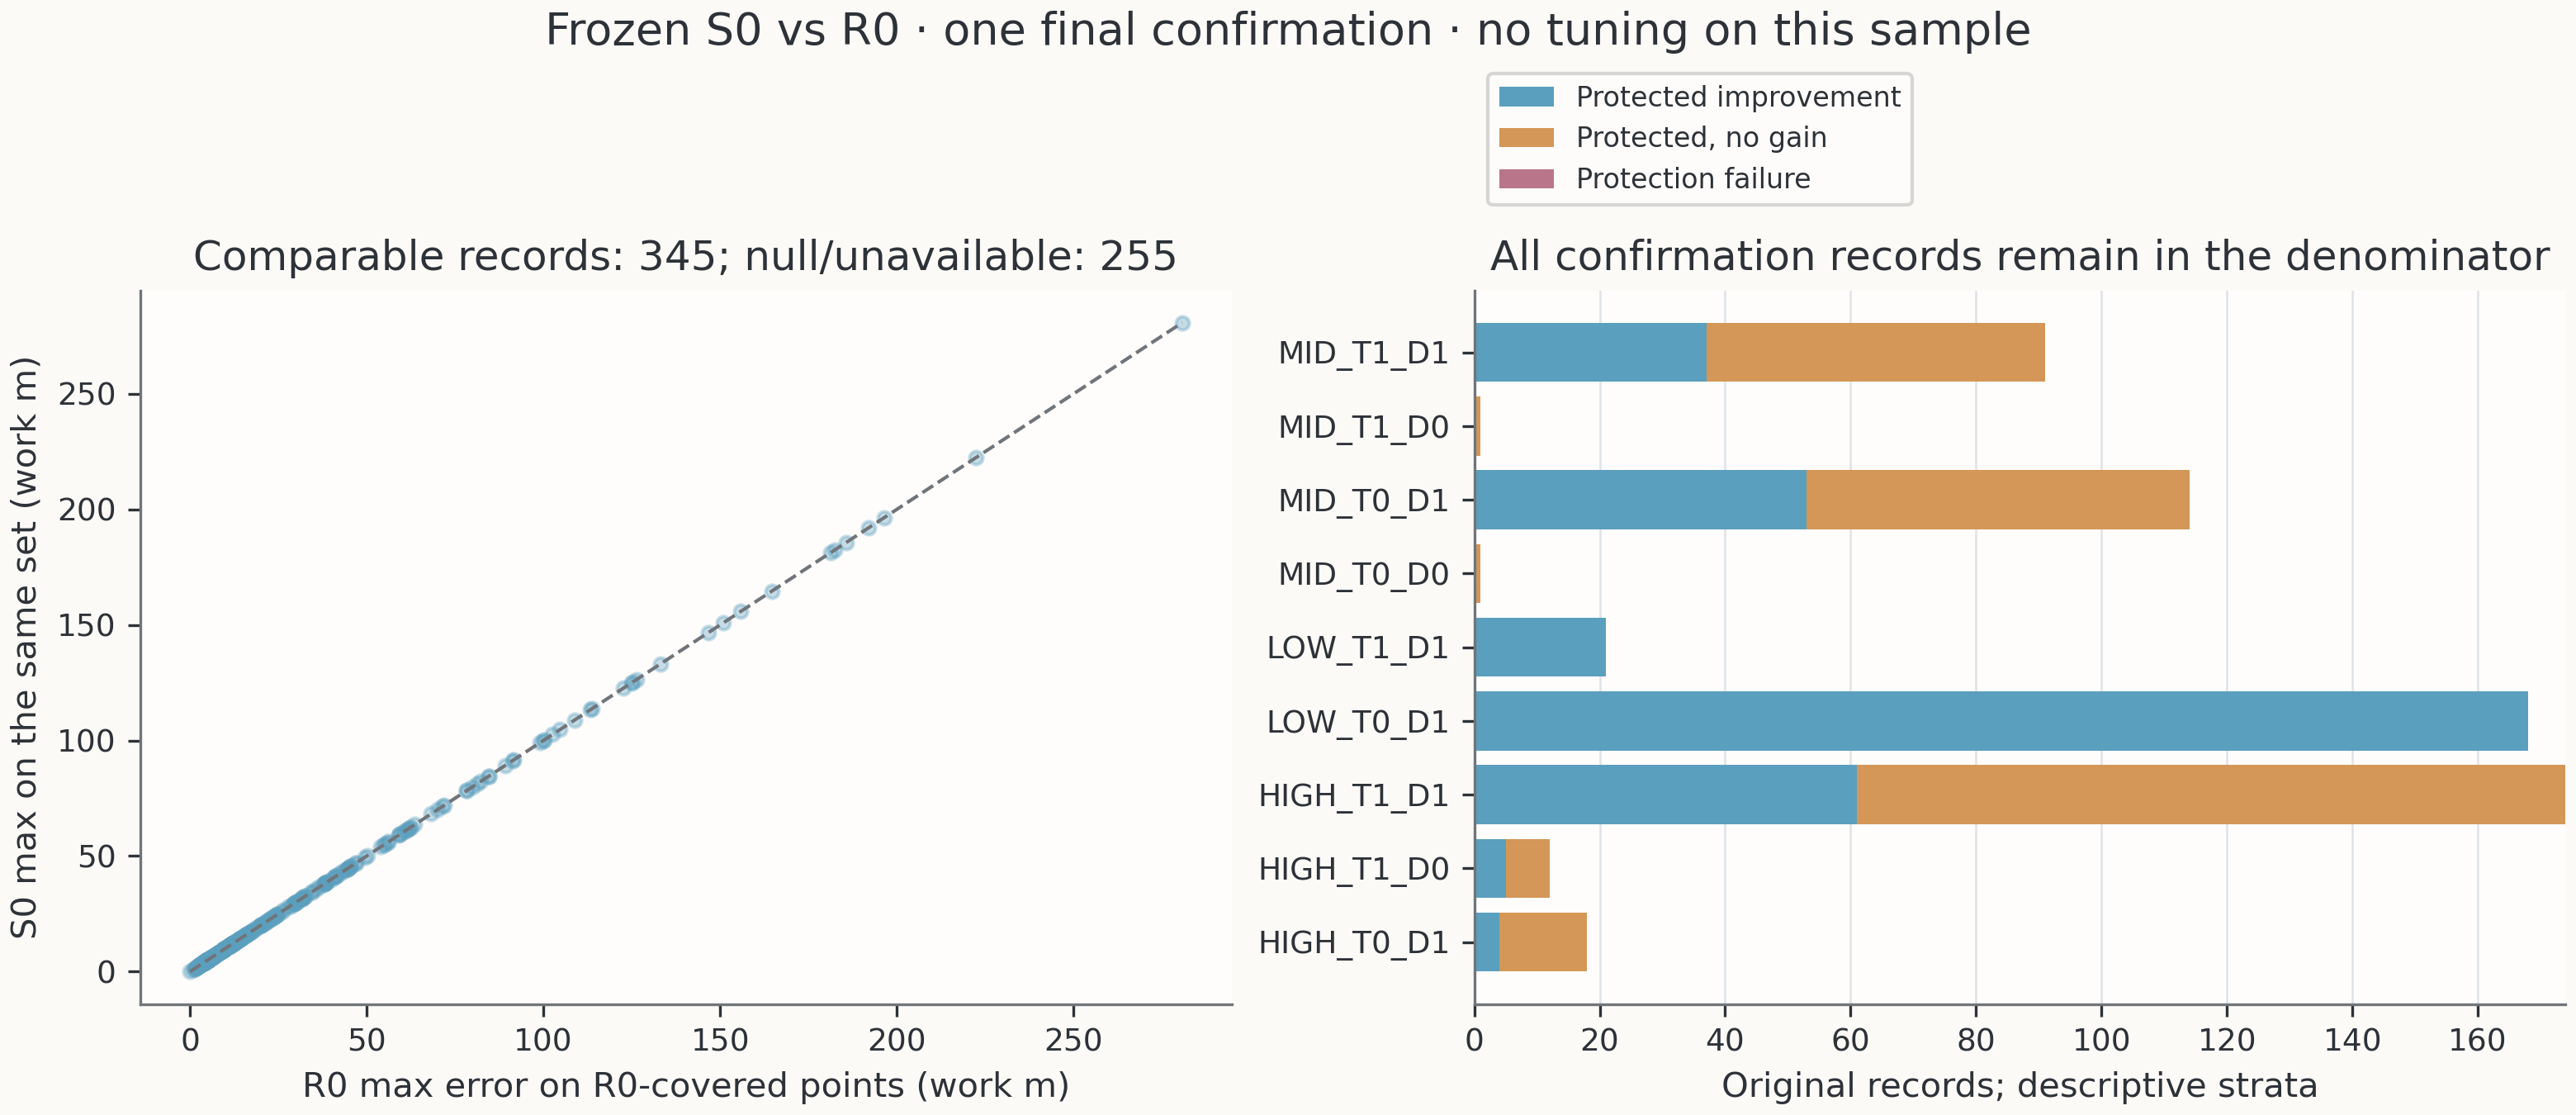

**已归档正式图：** goal3 / point_fates_and_coverage（历史解释材料）

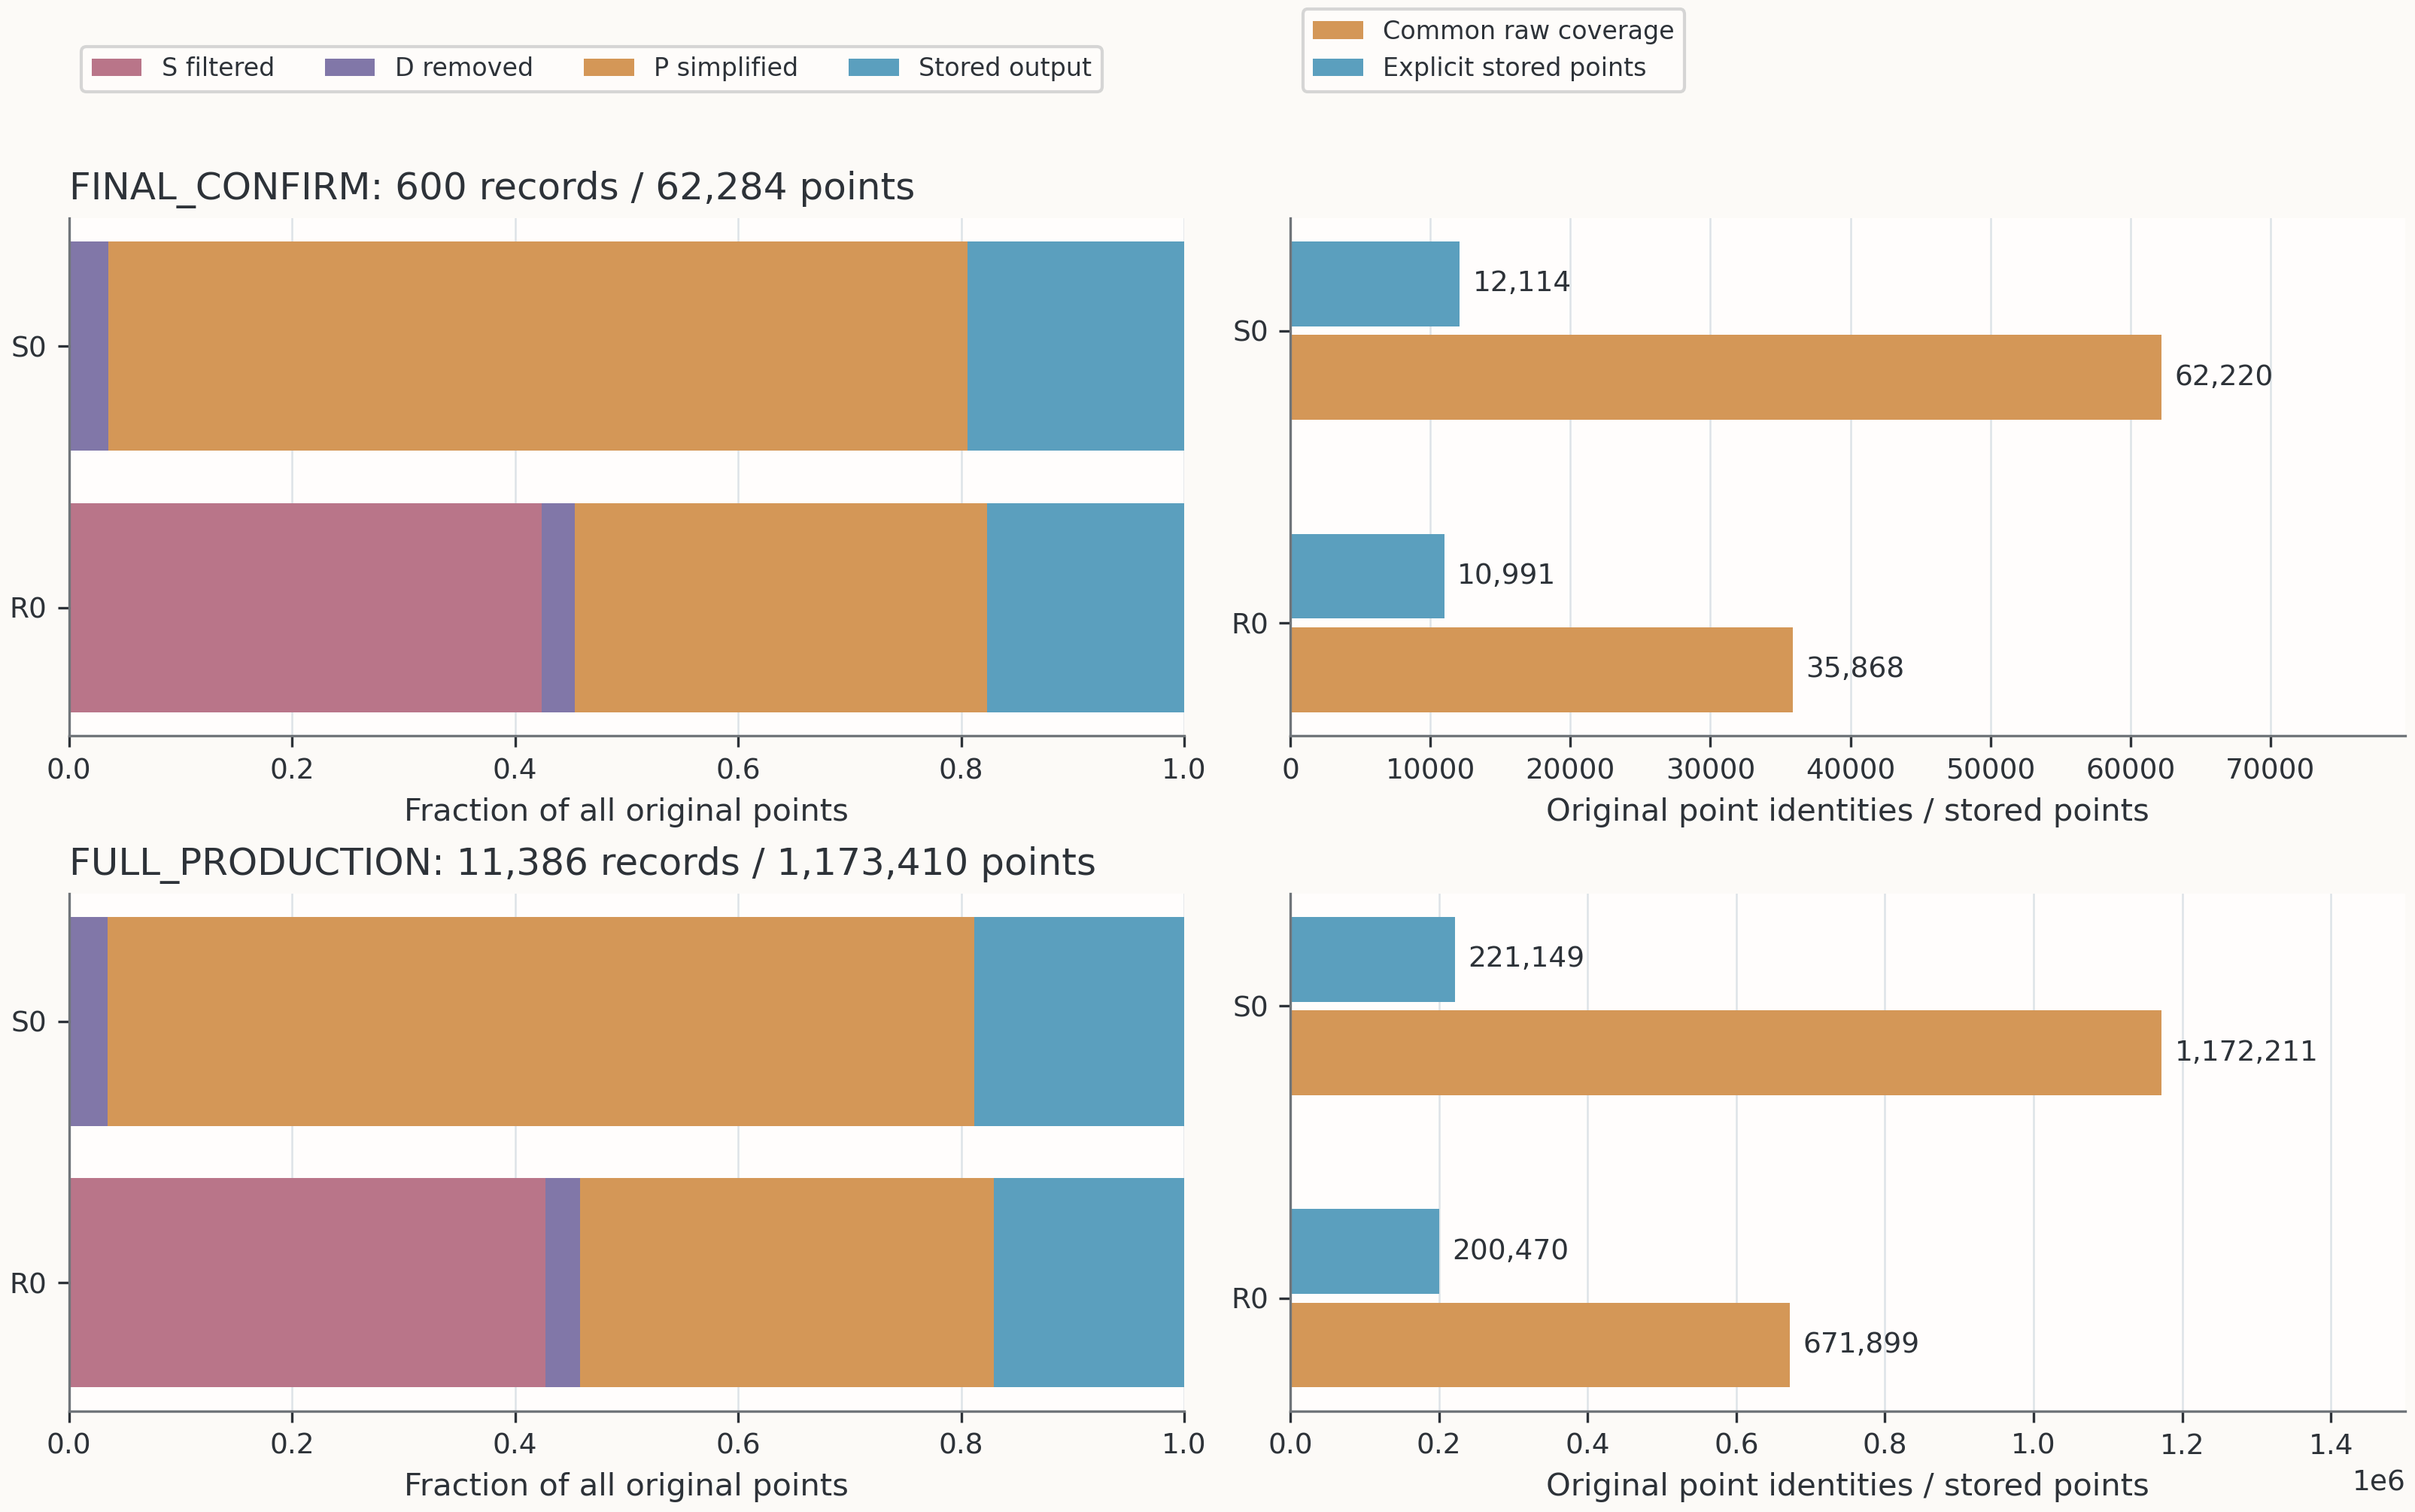

**已归档正式图：** goal3 / production_trajectory_cases（历史解释材料）

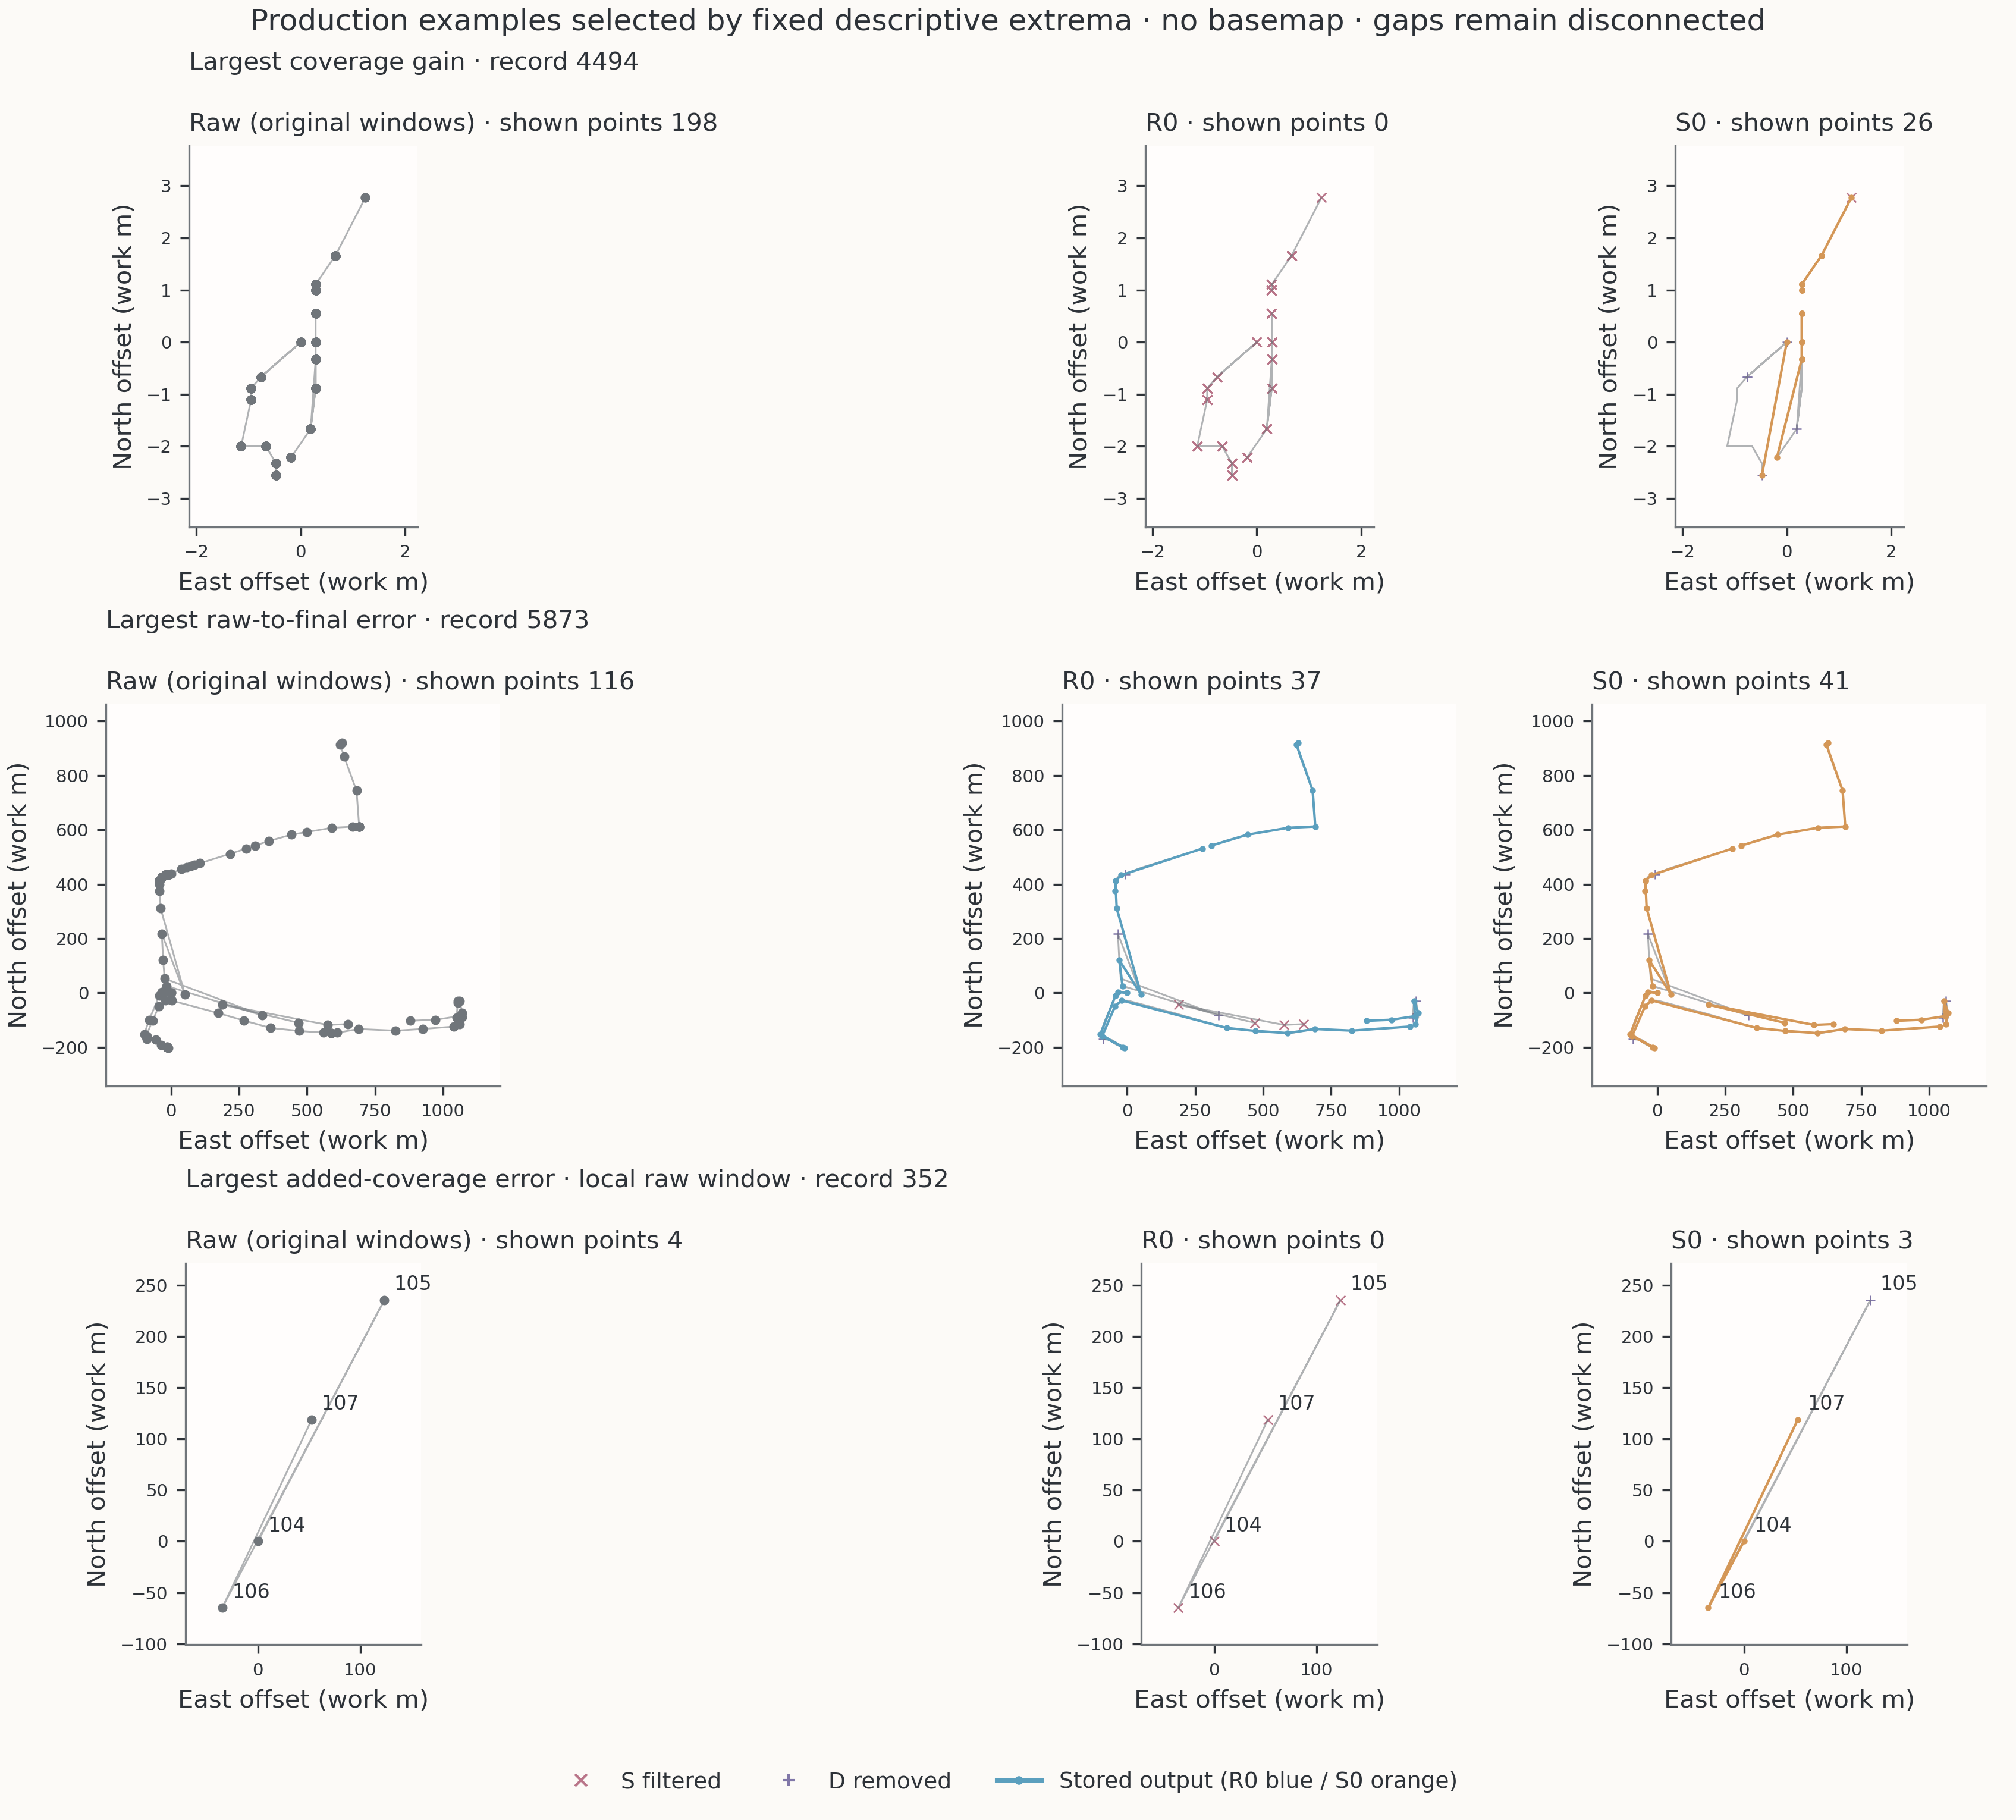

In [11]:
production_recompute=run_logged('production',lambda:recompute_production(WORK/'production'))
assert production_recompute['raw_records']==len(raw)==11386
rebuilt_production=read_json(WORK/'production'/'manifest.json')
show([{'strategy':cid,**values} for cid,values in rebuilt_production['record_metrics'].items()],
     ['strategy','n_records','n_input','n_filtered','n_direction_removed','n_dp_removed','n_final',
      'common_covered_points','n_no_output_records','raw_break_crossings','dp_max_error'])
show([{'strategy':cid,'parameters':entry['parameters'],'order':entry['order'],
       'conditional_rule':entry.get('conditional_rule')} for cid,entry in rebuilt_production['strategies'].items()])
confirm_path,confirmation=current_manifest('FINAL_CONFIRM')
print('最终确认（历史冻结执行，与全量统计分开）：',len(confirmation['input_ids']),'条。')
show([{'pair':key,**value} for key,value in confirmation['comparisons'].items()])
print('全量分片字节哈希重算一致：',production_recompute['actual_full_shard_hash_equality'])
recomputed_figure('production','recomputed_point_fates')
recomputed_figure('production','recomputed_trajectory_case')
print('以下为已核验 G3 阶段归档图；与上方本次 raw 复算重绘图分开。')
figure('development_candidates',phase='goal3')
figure('incumbent_decision_path',phase='goal3')
figure('selection_tradeoffs',phase='goal3')
figure('final_confirmation_pairs',phase='goal3')
figure('point_fates_and_coverage',phase='goal3')
figure('production_trajectory_cases',phase='goal3')

## 8. 完成读数与复现边界

保存的 Notebook 输出来自本次实际 full 路径；历史模式和记忆的完整复算见另一份系统完成版。研究结论仍区分范围内支持、未证明收益、权衡和工程已验证。源datum未证实、无噪声真值、记录不等于独立用户；使用这些局限解释结果，不把它们填成已经解决。

In [12]:
receipt={'notebook':'basic','historical_record_candidate_recomputations':parameter_recompute['candidate_record_recomputations'],
         'production_raw_records':production_recompute['raw_records'],'production_record_evaluations':production_recompute['record_evaluations'],
         'synthetic_pipeline_recomputations':synthetic_recomputations,'known_exposed_pilot_runs':1,
         'new_parameter_plots':parameter_recompute['raw_recomputed_plots'],'new_production_plots':production_recompute['raw_recomputed_plots']}

assert digest(memory_path)==memory_hash_before
assert digest(raw_path)==stage['data']['raw_sha256']
assert provider_observation['attempted_new_calls']==0
ExperimentProvider.call=_original_experiment_call
CodexProvider.call=_original_governance_call
receipt.update({'status':'VERIFIED','mode':MODE,'python_version':platform.python_version(),
                'new_model_call_attempts_observed':provider_observation['attempted_new_calls'],
                'memory_sha256_before':memory_hash_before,'memory_sha256_after':digest(memory_path),
                'raw_sha256_unchanged':digest(raw_path)==stage['data']['raw_sha256'],
                'historical_recompute_is_new_live':False,
                'execution_artifact_directory_name':WORK.name,
                'execution_directory_source':'SC_LAB1_RECOMPUTE_WORK' if explicit_work else 'new_temporary_directory',
                'module_root_matches_current_project':MODULE_ROOT.resolve()==ROOT})
write_json(WORK/'notebook_receipt.json',receipt)
print(json.dumps(receipt,ensure_ascii=False,indent=2))
print('本次新模型调用0；历史提议复算不作为新LIVE。网页GPT二重审核仍由外部实际审核决定。')

{
  "notebook": "basic",
  "historical_record_candidate_recomputations": 9720,
  "production_raw_records": 11386,
  "production_record_evaluations": 22772,
  "synthetic_pipeline_recomputations": 19,
  "known_exposed_pilot_runs": 1,
  "new_parameter_plots": {
    "figure_count": 2,
    "manifest_path": "figures/figure_manifest.json",
    "manifest_sha256": "c164ab71c54cae4b82027be07ee8a9bee0b903836551fc16089b94724327d811",
    "plot_data_sha256": "5c4af348429fe64e2e6bceea20008541af32d9da6806bd7e5eba4410bc5e9320",
    "lineage": "newly recomputed raw results; historical targets used only for equality checks"
  },
  "new_production_plots": {
    "figure_count": 2,
    "manifest_path": "figures/figure_manifest.json",
    "manifest_sha256": "d73efbfa1529fcd5cc88bc1ce7830d868f4c0d24a2dd8cacd21e52f2d0c74af0",
    "plot_data_sha256": "828916a8583983f4791c97bce8c7eab4f39d069e2f80d6e011cdae79b1cb2765",
    "lineage": "newly recomputed raw results; historical targets used only for equality checks